# Phase 2 — MC-LIME : Multi-Class LIME

MC-LIME est une extension de LIME qui produit simultanément des scores d'importance
pour **chacun des 4 profils** (E+P+, E+P−, E−P+, E−P−).

Contrairement à LIME classique qui explique uniquement la classe prédite,
MC-LIME permet de voir pourquoi un étudiant est proche ou loin de chaque profil.

**Modèles retenus** : Random_Forest, XGBoost, Decision_Tree

**Structure :**
1. Chargement de l'evaluator
2. Imports
3. Classe MCLIMEEvaluator
4. Exécution
5. Consultation des résultats

## 1. Import

In [56]:
from MLEvaluator import MLEvaluator
from XAIEvaluator import XAIEvaluator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
os.makedirs('outputs', exist_ok=True)

from lime.lime_tabular import LimeTabularExplainer
print('✓ LIME disponible')

✓ LIME disponible


## 2. Chargement de l'evaluator

In [58]:
evaluator = MLEvaluator.load('evaluator.pkl')
print(f'Modèles disponibles : {list(evaluator.trained_models.keys())}')
print(f'Features           : {len(evaluator.feature_names)}')
print(f'Test set           : {evaluator.X_test.shape[0]} étudiants')

Evaluator chargé depuis 'evaluator.pkl'
   Modèles disponibles : ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']
Modèles disponibles : ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']
Features           : 184
Test set           : 26 étudiants


## 3. Classe MCLIMEEvaluator

MC-LIME utilise le même `LimeTabularExplainer` que LIME classique,
mais avec `top_labels=4` pour obtenir les scores sur les 4 classes simultanément.

Pour chaque instance et chaque modèle, on obtient un dictionnaire :
```
{
  'E+P+' : [('COURSE_ACCESS_MINUTES', -0.045), ('T_EXE_SUBMISSION_COUNT', -0.038), ...],
  'E+P-' : [('COURSE_ACCESS_MINUTES', +0.021), ...],
  'E-P+' : [...],
  'E-P-' : [...]
}
```

In [60]:

# ============================================================
# CLASSE MC-LIME
# ============================================================

class MCLIMEEvaluator(XAIEvaluator):
    """
    MC-LIME : Multi-Class LIME
    Génère des scores d'importance pour les 4 profils simultanément.

    Utilisation :
        evaluator = MLEvaluator.load('evaluator.pkl')
        mc = MCLIMEEvaluator(evaluator)
        mc.run()
    """


    def __init__(self, evaluator):
        super().__init__(evaluator) 
        self.explainer       = None
        self.mc_lime_results = {}
        self.export_rows     = []

    
    # ── BLOC 2 : Création de l'explainer ──────────────────────
    def create_explainer(self):
        """
        LimeTabularExplainer identique à LIME classique.
        La différence est dans explain_instance() avec top_labels=4.
        """
        from lime.lime_tabular import LimeTabularExplainer
        self.explainer = LimeTabularExplainer(
            self.X_train.values,
            feature_names=self.feature_names,
            class_names=self.CLASS_NAMES,
            mode='classification',
            discretize_continuous=False,
            random_state=42,
        )
        print('✓ LimeTabularExplainer créé (mode MC-LIME)')

    # ── BLOC 3 : Génération MC-LIME ───────────────────────────
    def generate_explanations(self):
        """
        Pour chaque modèle et chaque instance :
        - explain_instance avec top_labels=4 → scores pour les 4 profils
        - Stocke les contributions par classe
        """
        print('\n GÉNÉRATION MC-LIME (4 classes simultanées)')
        print('=' * 55)

        for model_name, model in self.trained_models.items():
            print(f'\n  {model_name}...')

            if not hasattr(model, 'predict_proba'):
                print(f'  → pas de predict_proba, ignoré')
                continue

            model_results = []

            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices:
                    try:
                        instance = self.X_test.iloc[sample_idx].values

                        predicted  = int(model.predict([instance])[0])
                        true_label = int(self.y_test.iloc[sample_idx])
                        if predicted != true_label:
                            print(f'     {model_name} se trompe sur instance {sample_idx} → ignorée')
                            continue

                        exp = self.explainer.explain_instance(
                            instance,
                            model.predict_proba,
                            num_features=min(10, len(self.feature_names)),
                            top_labels=4,  # ← MC-LIME : toutes les classes
                        )

                        # Récupération des scores par classe
                        scores_par_classe = {}
                        for label_idx in exp.available_labels():
                            class_label = self.CLASS_NAMES[label_idx]
                            scores_par_classe[class_label] = exp.as_list(label=label_idx)

                        model_results.append({
                            'instance_id'      : sample_idx,
                            'profil_reel'      : class_name,
                            'true_label'       : int(self.y_test.iloc[sample_idx]),
                            'predicted_label'  : int(model.predict([instance])[0]),
                            'prediction_proba' : model.predict_proba([instance])[0].tolist(),
                            'scores_par_classe': scores_par_classe,
                        })

                    except Exception as e:
                        print(f'     Échec sample {sample_idx} : {e}')

            self.mc_lime_results[model_name] = model_results
            print(f'    → {len(model_results)} explications générées ✓')

    # ── BLOC 4 : Visualisation ────────────────────────────────
    def plot_explanations(self):
        """
        Pour chaque instance, affiche 4 graphiques côte à côte :
        un par profil, montrant les contributions de features.
        Permet de voir comment les features poussent vers chaque profil.
        """
        print('\n VISUALISATION MC-LIME')
        print('=' * 55)

        colors_profils = {
            'E+P+': '#1D9E75',
            'E+P-': '#7F77DD',
            'E-P+': '#EF9F27',
            'E-P-': '#D85A30',
        }

        for model_name, results in self.mc_lime_results.items():
            for res in results:
                scores = res['scores_par_classe']
                if not scores:
                    continue

                n_classes = len(scores)
                fig, axes = plt.subplots(1, n_classes,
                                         figsize=(5 * n_classes, 6))
                if n_classes == 1:
                    axes = [axes]

                true_label  = self.CLASS_NAMES[res['true_label']]
                pred_label  = self.CLASS_NAMES[res['predicted_label']]

                fig.suptitle(
                    f'MC-LIME — {model_name} — Instance {res["instance_id"]}\n'
                    f'Profil réel : {true_label} | Prédit : {pred_label}',
                    fontsize=13, fontweight='bold'
                )

                for ax, (class_label, contributions) in zip(axes, scores.items()):
                    if not contributions:
                        continue

                    features, contribs = zip(*contributions)
                    bar_colors = [
                        '#1D9E75' if c > 0 else '#D85A30'
                        for c in contribs
                    ]

                    y_pos = np.arange(len(features))
                    bars = ax.barh(y_pos, contribs,
                                   color=bar_colors, alpha=0.8)
                    ax.set_yticks(y_pos)
                    ax.set_yticklabels(
                        [f[:25] + '...' if len(f) > 25 else f
                         for f in features],
                        fontsize=7
                    )

                    mn, mx = min(contribs), max(contribs)
                    pad = (mx - mn) * 0.2 if mx != mn else 0.005
                    ax.set_xlim(mn - pad, mx + pad)
                    ax.axvline(0, color='black',
                               linewidth=0.8, linestyle='--')

                    # Encadrer la classe prédite
                    border_color = colors_profils.get(class_label, 'gray')
                    for spine in ax.spines.values():
                        spine.set_edgecolor(border_color)
                        spine.set_linewidth(
                            2.5 if class_label == pred_label else 0.5
                        )

                    ax.set_title(
                        f'Profil {class_label}'
                        + (' ← PRÉDIT' if class_label == pred_label else ''),
                        fontsize=10, fontweight='bold',
                        color=border_color
                    )
                    ax.grid(axis='x', alpha=0.3)

                    # Labels sur les barres
                    for bar, val in zip(bars, contribs):
                        w = bar.get_width()
                        offset = 0.02 * max(abs(w), 0.001)
                        ax.text(
                            w + offset if w >= 0 else w - offset,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.3f}',
                            ha='left' if w >= 0 else 'right',
                            va='center', fontsize=6
                        )

                plt.tight_layout()
                plt.savefig(
                    f'outputs/mclime_{model_name}_instance{res["instance_id"]}.png',
                    dpi=150, bbox_inches='tight'
                )
                plt.show()

    # ── BLOC 5 : Visualisation comparative des profils ────────
    def plot_feature_importance_by_profile(self):
        """
        Pour chaque modèle : heatmap des contributions moyennes
        par feature et par profil.
        Permet de voir quelles features discriminent le plus chaque profil.
        """
        print('\n HEATMAP : contributions moyennes par profil')

        for model_name, results in self.mc_lime_results.items():
            # Collecter toutes les contributions
            data = {cls: {} for cls in self.CLASS_NAMES}

            for res in results:
                for class_label, contributions in res['scores_par_classe'].items():
                    for feat, contrib in contributions:
                        if feat not in data[class_label]:
                            data[class_label][feat] = []
                        data[class_label][feat].append(contrib)

            # Moyenne par feature et par classe
            rows = []
            all_features = set()
            for cls, feats in data.items():
                for feat in feats:
                    all_features.add(feat)

            for feat in sorted(all_features):
                row = {'Feature': feat}
                for cls in self.CLASS_NAMES:
                    vals = data[cls].get(feat, [0])
                    row[cls] = round(np.mean(vals), 4)
                rows.append(row)

            df_heat = pd.DataFrame(rows).set_index('Feature')

            # Top 15 features par importance absolue moyenne
            df_heat['abs_mean'] = df_heat.abs().mean(axis=1)
            df_heat = df_heat.sort_values('abs_mean', ascending=False).head(15)
            df_heat = df_heat.drop(columns=['abs_mean'])

            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(
                df_heat,
                annot=True, fmt='.3f',
                cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5
            )
            ax.set_title(
                f'MC-LIME — {model_name}\n'
                f'Contributions moyennes par feature et par profil',
                fontsize=13, fontweight='bold'
            )
            ax.set_xlabel('Profil')
            ax.set_ylabel('Feature')
            plt.tight_layout()
            plt.savefig(
                f'outputs/mclime_heatmap_{model_name}.png',
                dpi=150, bbox_inches='tight'
            )
            plt.show()

    # ── BLOC 6 : Export CSV ───────────────────────────────────
    def export(self, filename='outputs/mclime_explanations.csv'):
        """
        Exporte toutes les explications MC-LIME en CSV.
        Format : une ligne par (modèle, instance, classe cible, feature).
        Ce fichier sera fusionné avec LIME, SHAP, DiCE et CEM.
        """
        rows = []
        for model_name, results in self.mc_lime_results.items():
            for res in results:
                base = {
                    'model'        : model_name,
                    'instance_id'  : res['instance_id'],
                    'profil_reel'  : res['profil_reel'],
                    'vrai_label'   : self.CLASS_NAMES[res['true_label']],
                    'predit_label' : self.CLASS_NAMES[res['predicted_label']],
                    'methode'      : 'MC-LIME',
                }
                # Probabilités
                for i, prob in enumerate(res['prediction_proba']):
                    base[f'proba_{self.CLASS_NAMES[i]}'] = round(prob, 4)

                # Une ligne par (classe cible, feature)
                for class_label, contributions in \
                        res['scores_par_classe'].items():
                    for feat, contrib in contributions:
                        row = base.copy()
                        row['classe_cible'] = class_label
                        row['feature']      = feat
                        row['contribution'] = round(contrib, 6)
                        row['abs_contrib']  = round(abs(contrib), 6)
                        rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f'✓ Export : {filename}')
        print(f'  {len(rows)} lignes | '
              f'{df["instance_id"].nunique()} instances | '
              f'{df["model"].nunique()} modèles')
        return df

    # ── MÉTHODE PRINCIPALE ────────────────────────────────────
    def run(self):
        """
        Lance tout le pipeline MC-LIME dans l'ordre :
    
        1. Sélectionner les échantillons par classe
        2. Créer l'explainer MC-LIME
        3. Générer les explications (4 classes simultanées)
        4. Visualiser les résultats par instance
        5. Visualiser la heatmap par profil
        6. Exporter le CSV
        """
        print(" LANCEMENT DU PIPELINE MC-LIME")
        print("=" * 70)
    
        # Étape 1 — Sélection des échantillons
        self.select_samples()
    
        # Étape 2 — Création de l'explainer
        self.create_explainer()
    
        # Étape 3 — Génération des explications
        self.generate_explanations()
    
        # Étape 4 — Visualisation par instance
        print("\n VISUALISATION DES EXPLICATIONS")
        print("=" * 70)
        self.plot_explanations()
    
        # Étape 5 — Heatmap par profil
        self.plot_feature_importance_by_profile()
    
        # Étape 6 — Export
        self.export()
    
        print("\n PIPELINE MC-LIME TERMINÉ !")

## 4. Exécution

 LANCEMENT DU PIPELINE MC-LIME

SÉLECTION DES INSTANCES
Mapping : {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}

E+P+ : 5 avec consensus / 7 totales
  → 4 sélectionnées ✓

E+P- : 2 avec consensus / 4 totales
  → 2 disponible(s) ⚠️

E-P+ : 9 avec consensus / 9 totales
  → 4 sélectionnées ✓

E-P- : 3 avec consensus / 6 totales
  → 3 disponible(s) ⚠️

✓ Total : 13 instances
✓ LimeTabularExplainer créé (mode MC-LIME)

🔍 GÉNÉRATION MC-LIME (4 classes simultanées)

  Decision_Tree...
    ⚠️ Decision_Tree se trompe sur instance 10 → ignorée
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector E

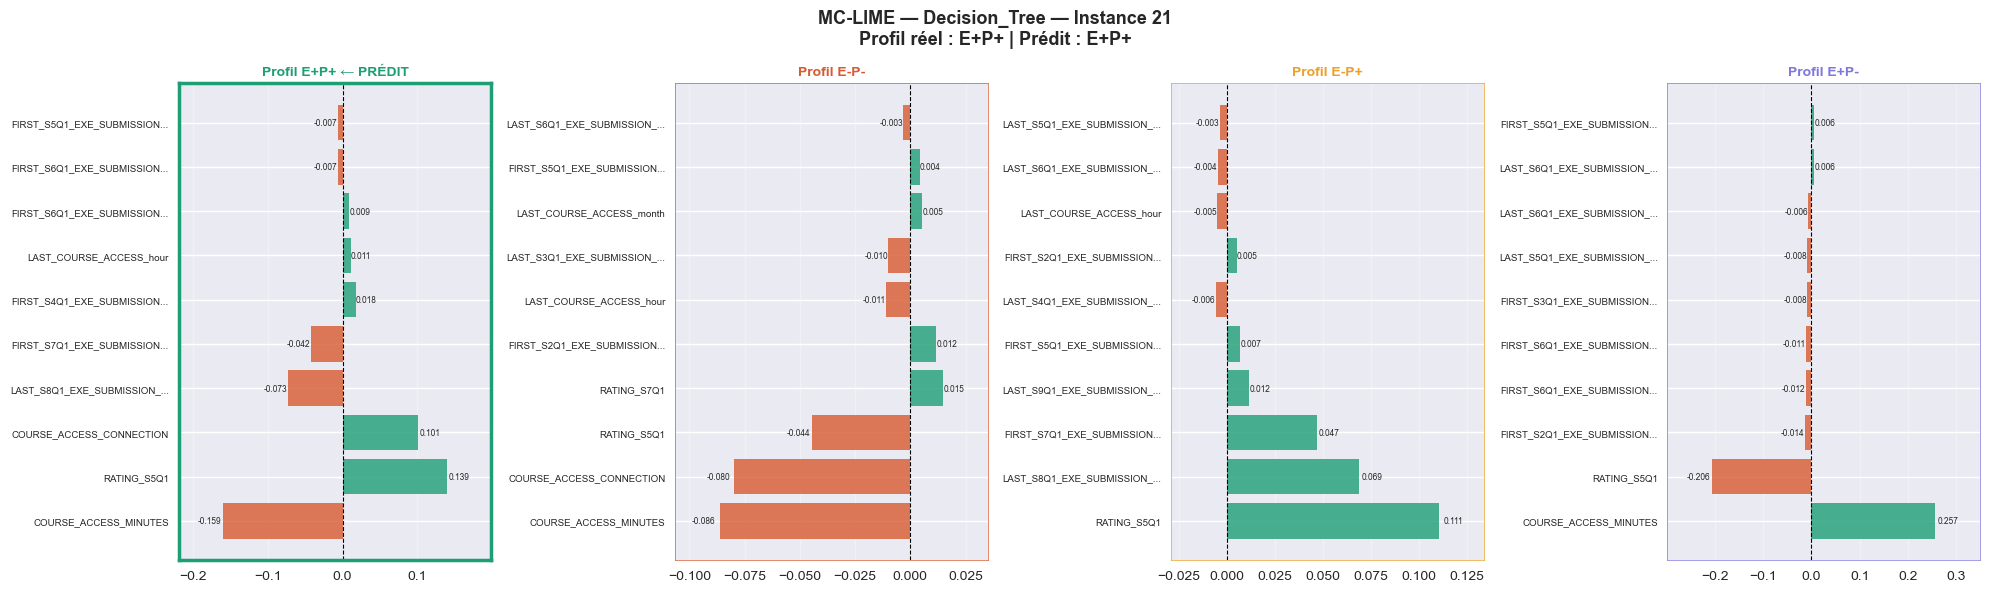

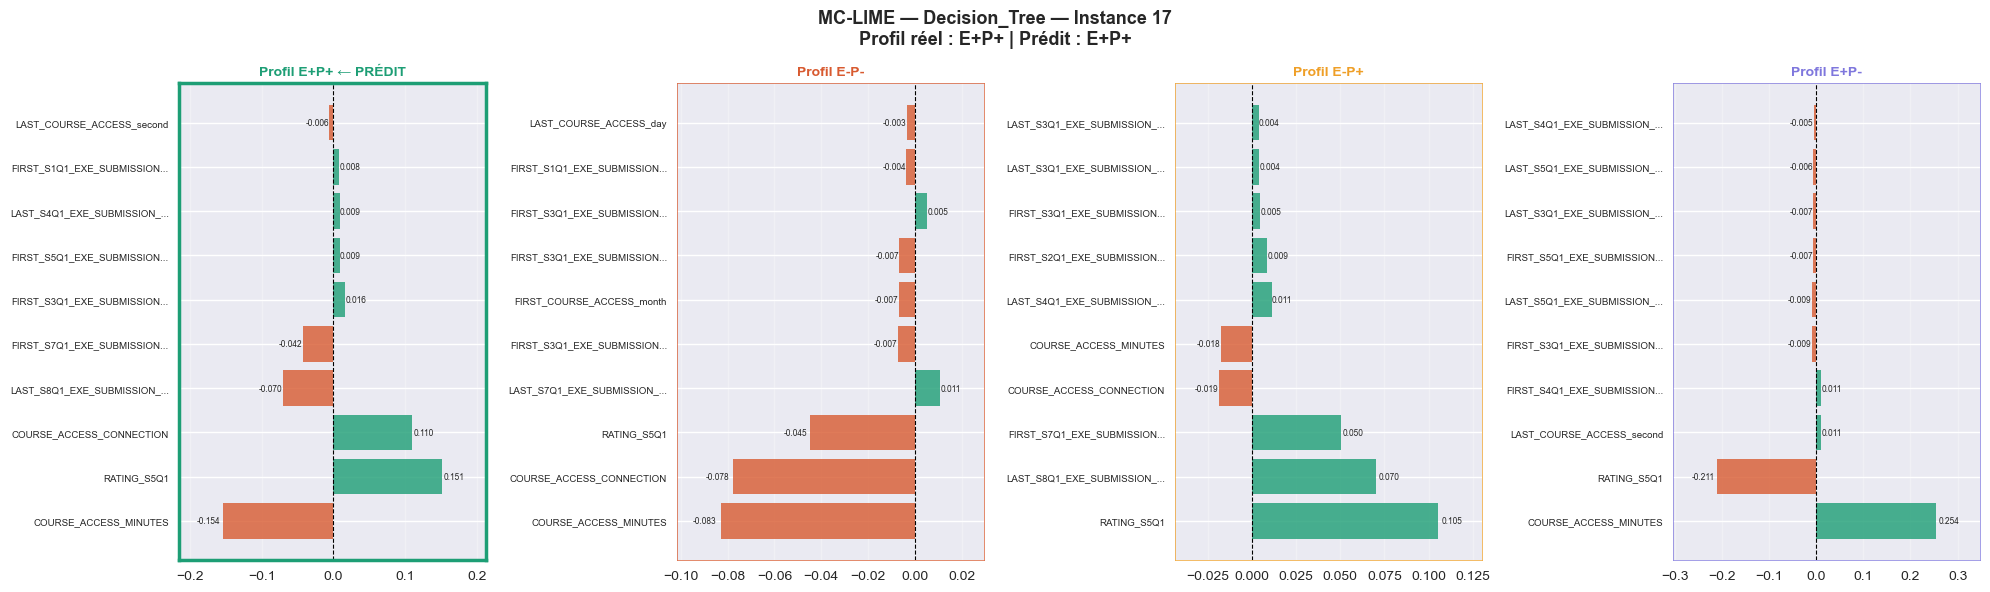

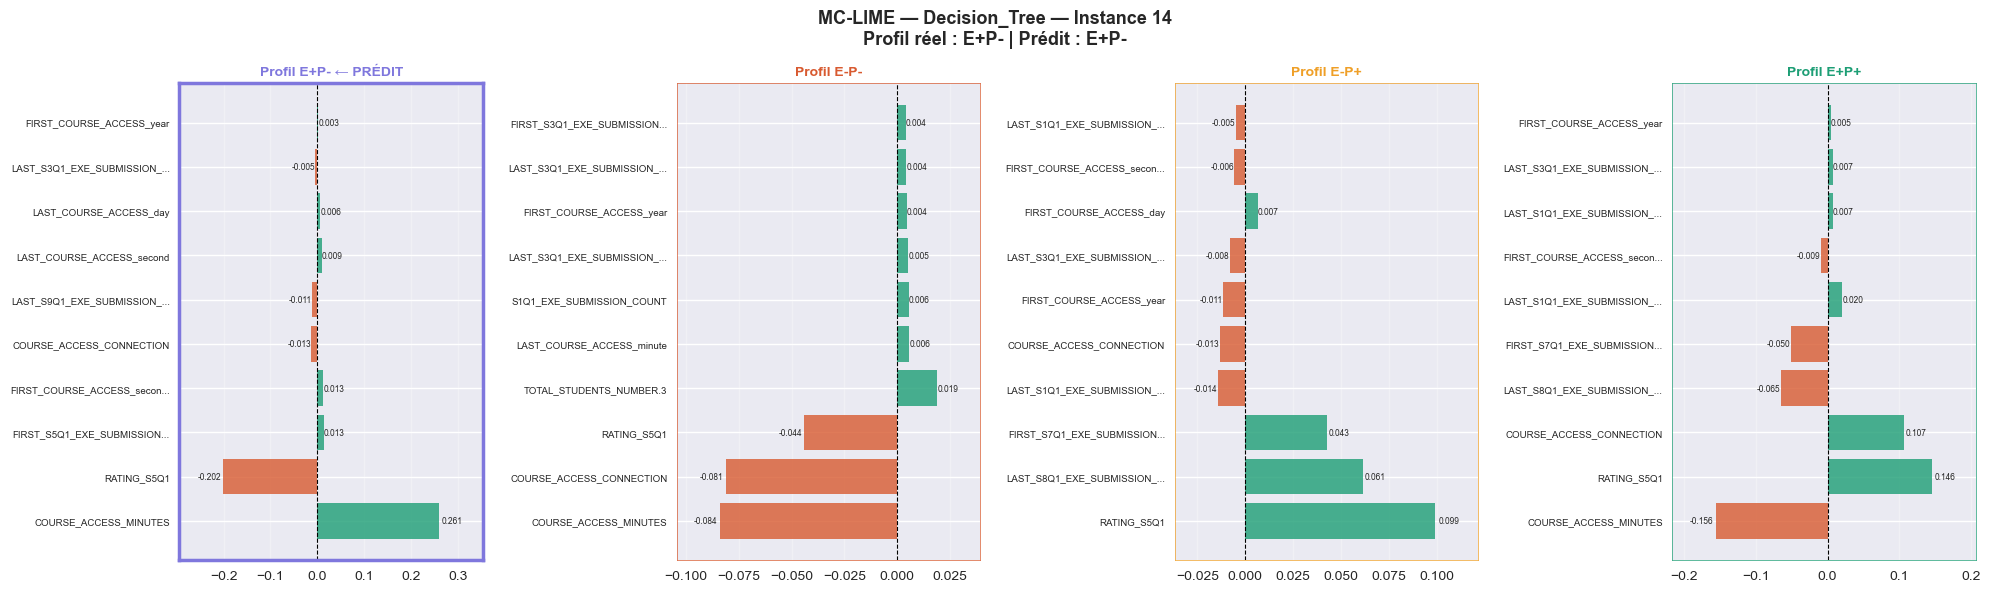

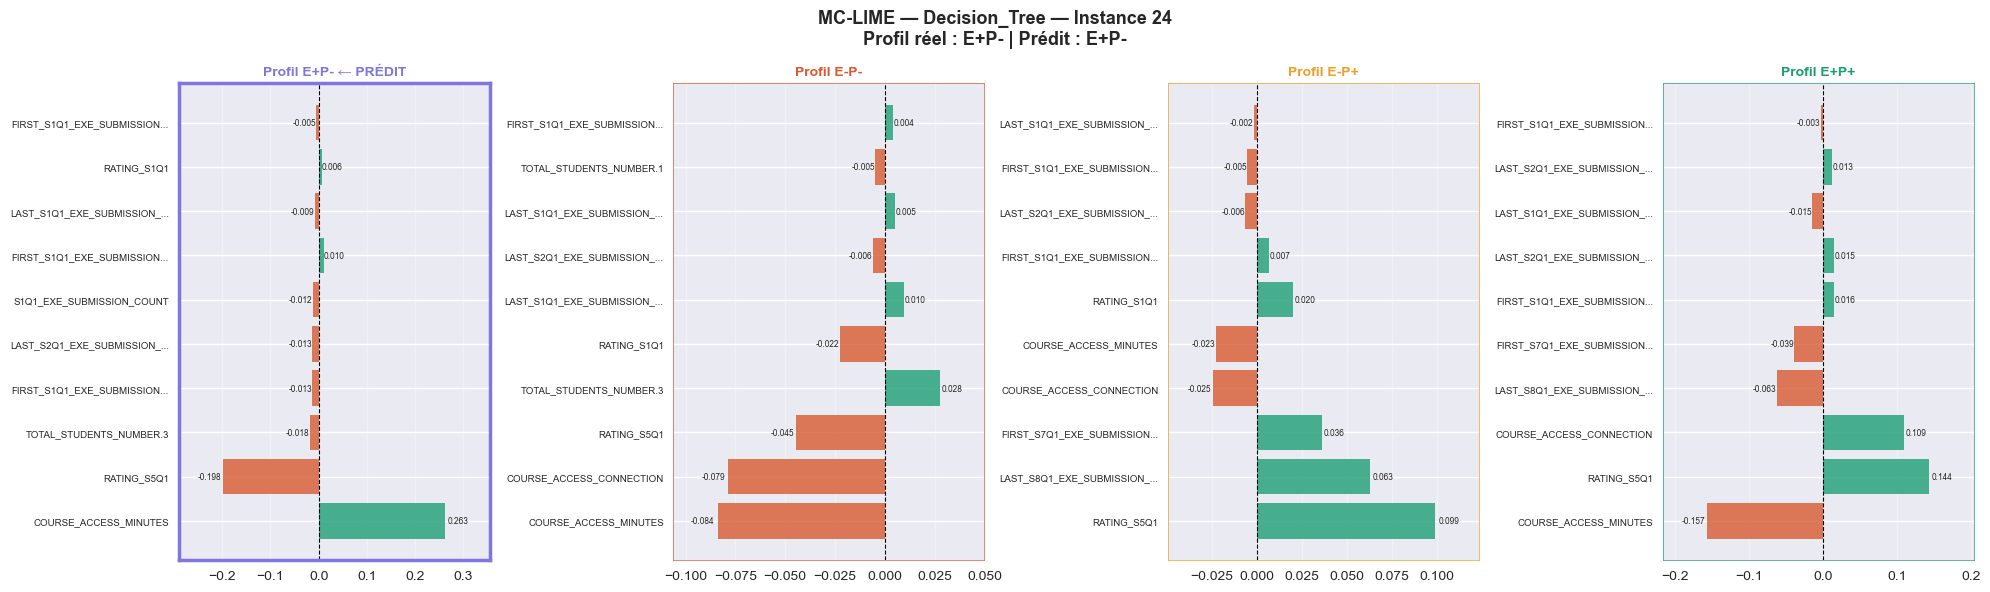

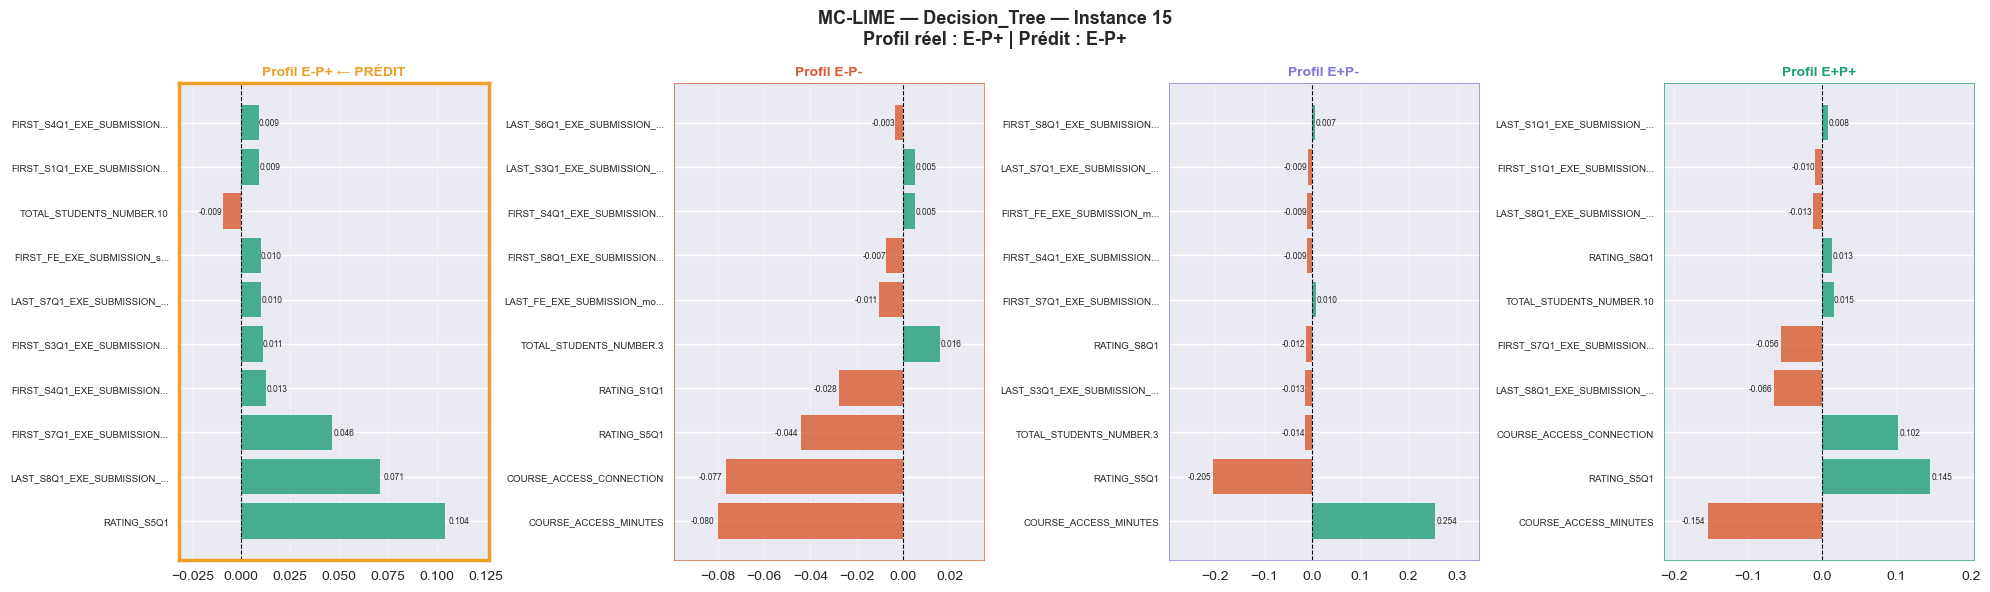

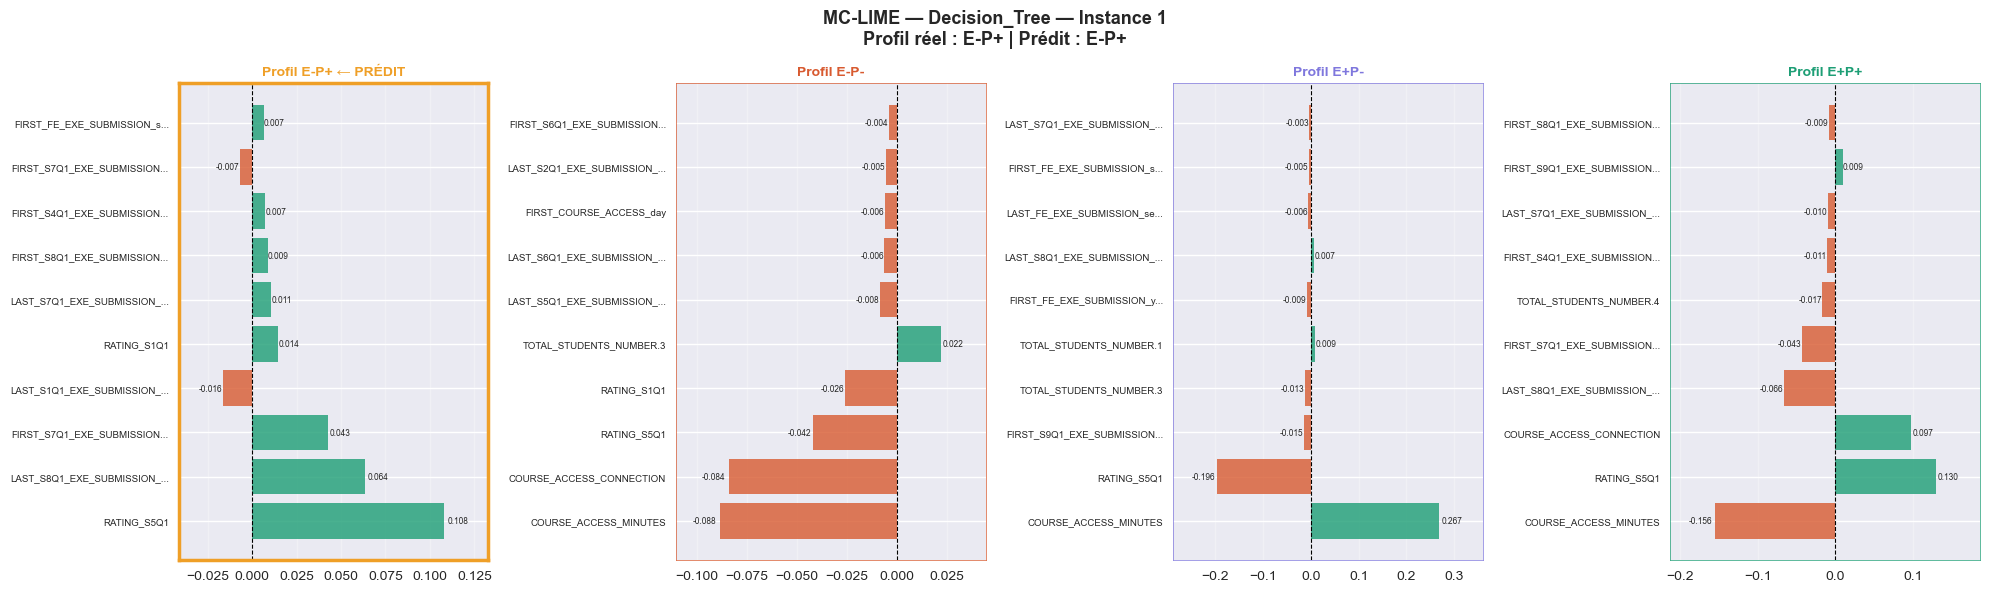

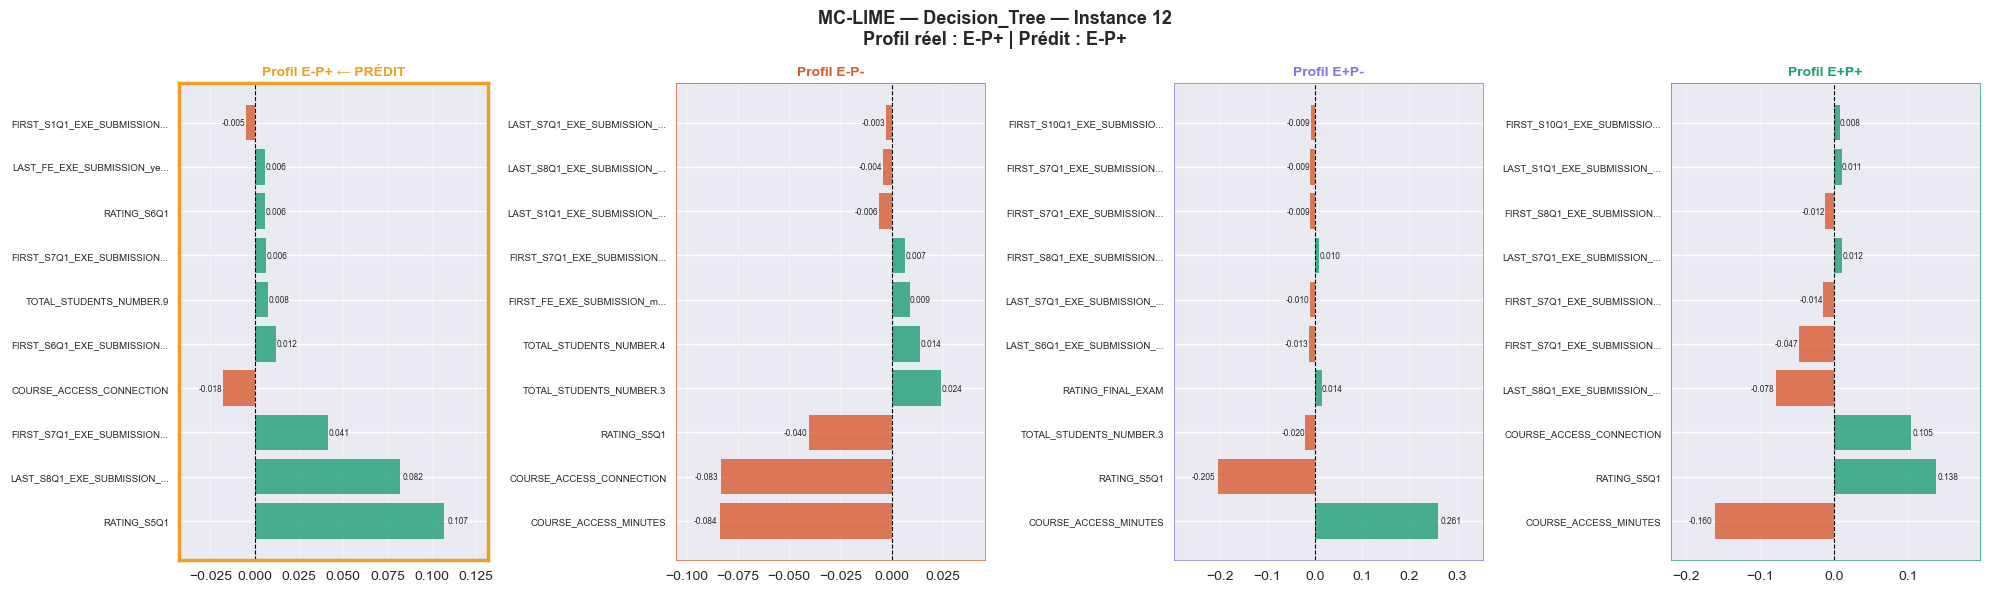

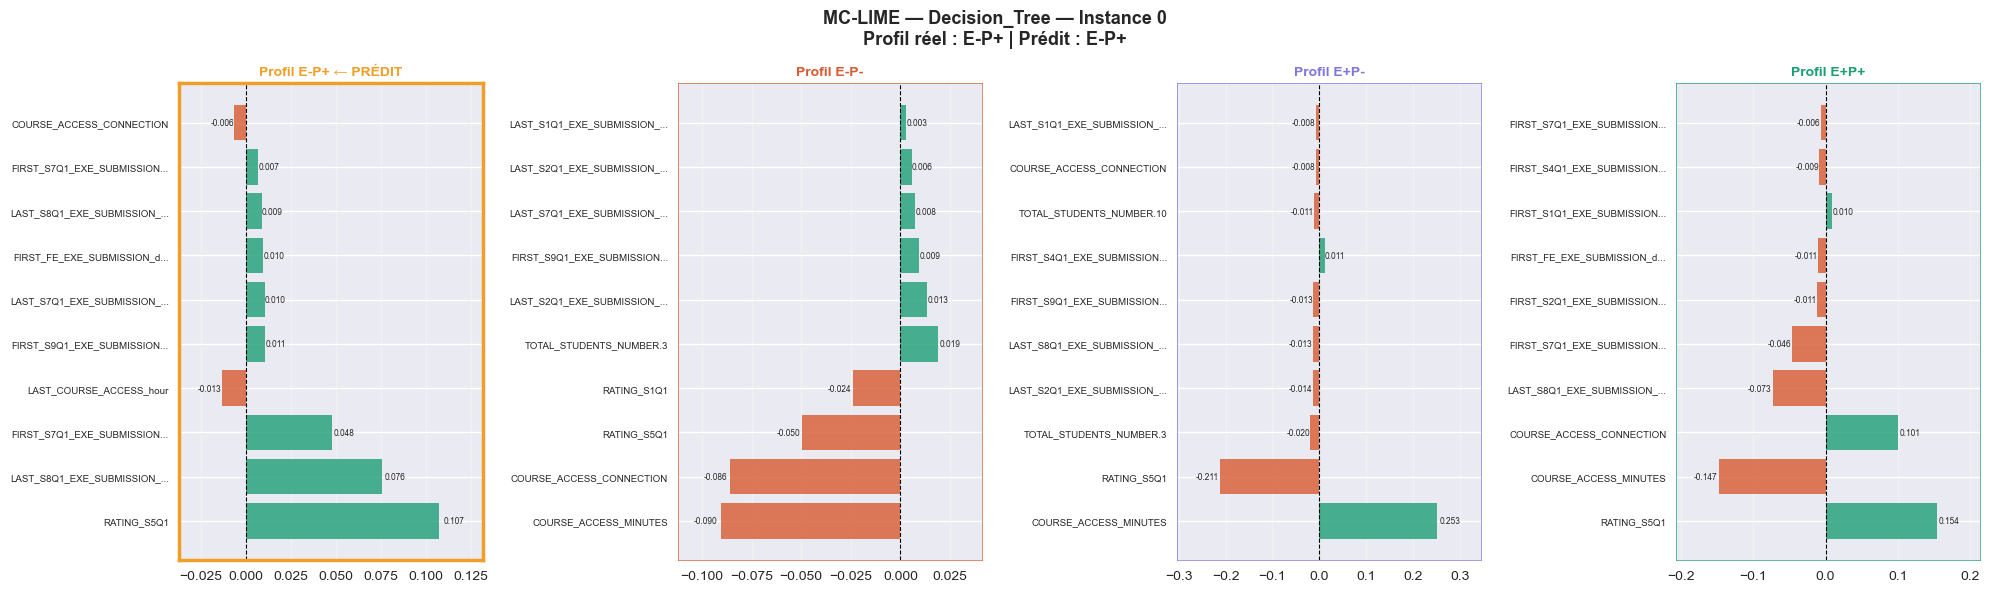

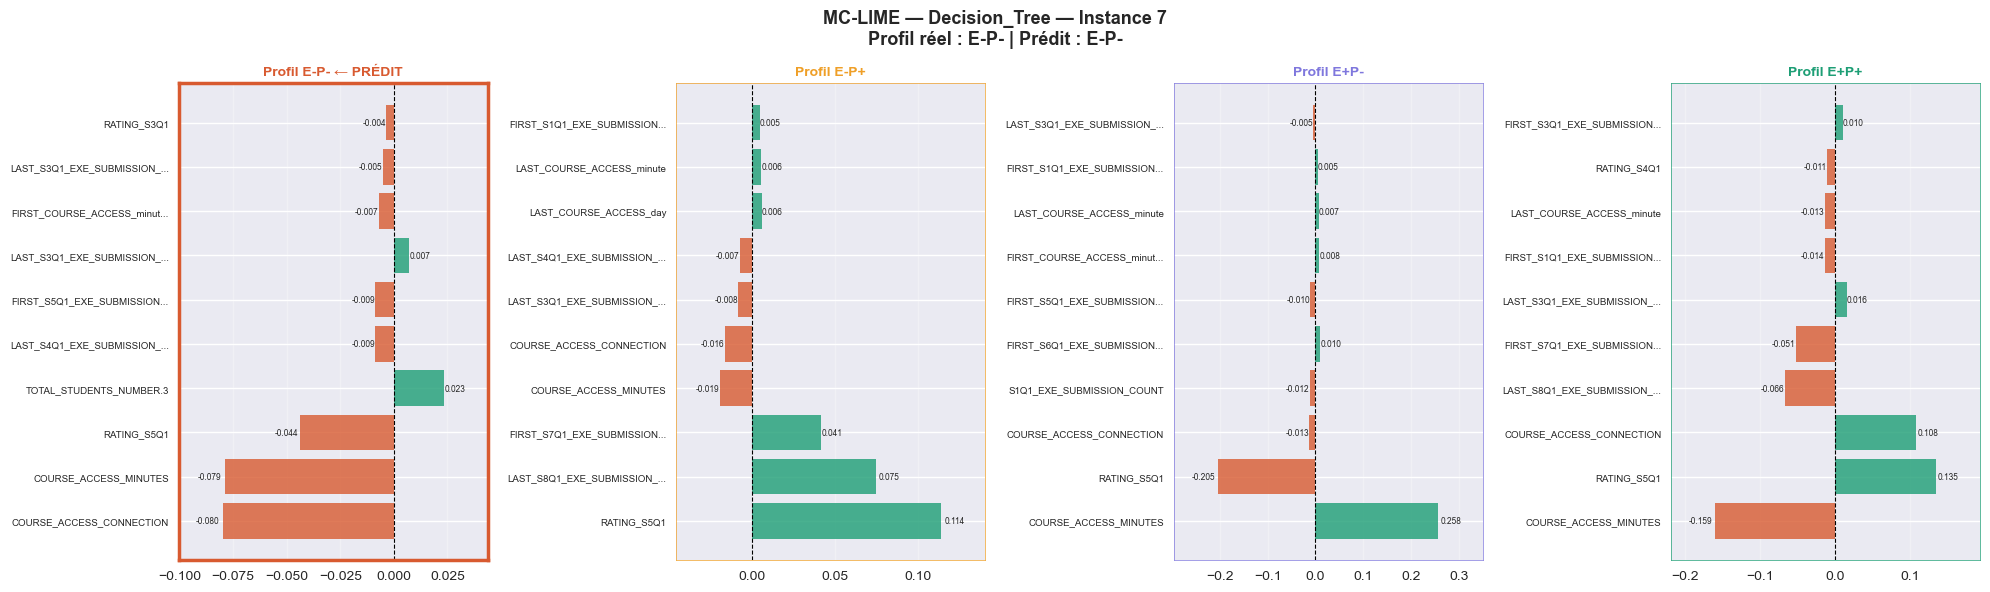

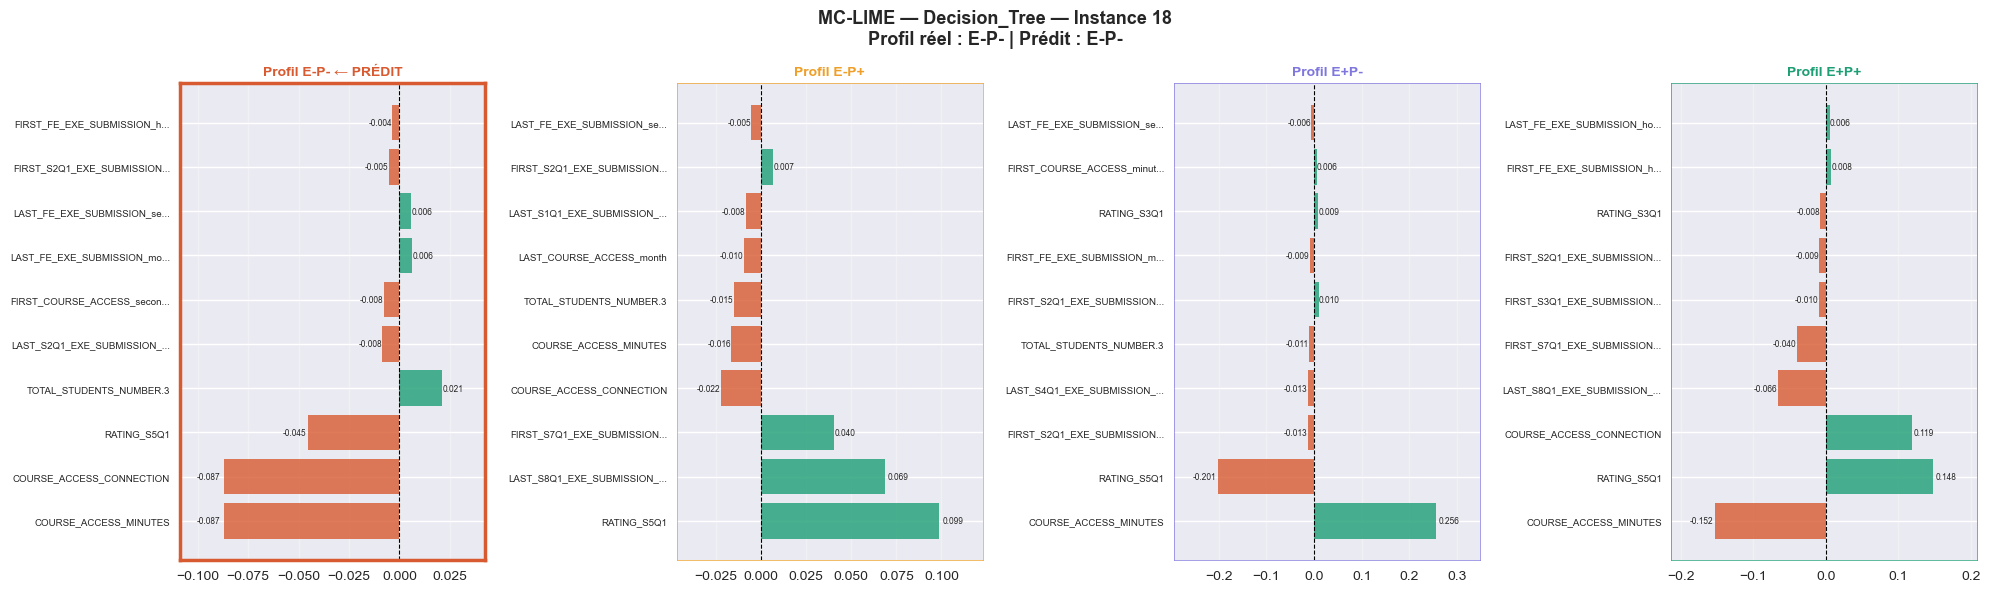

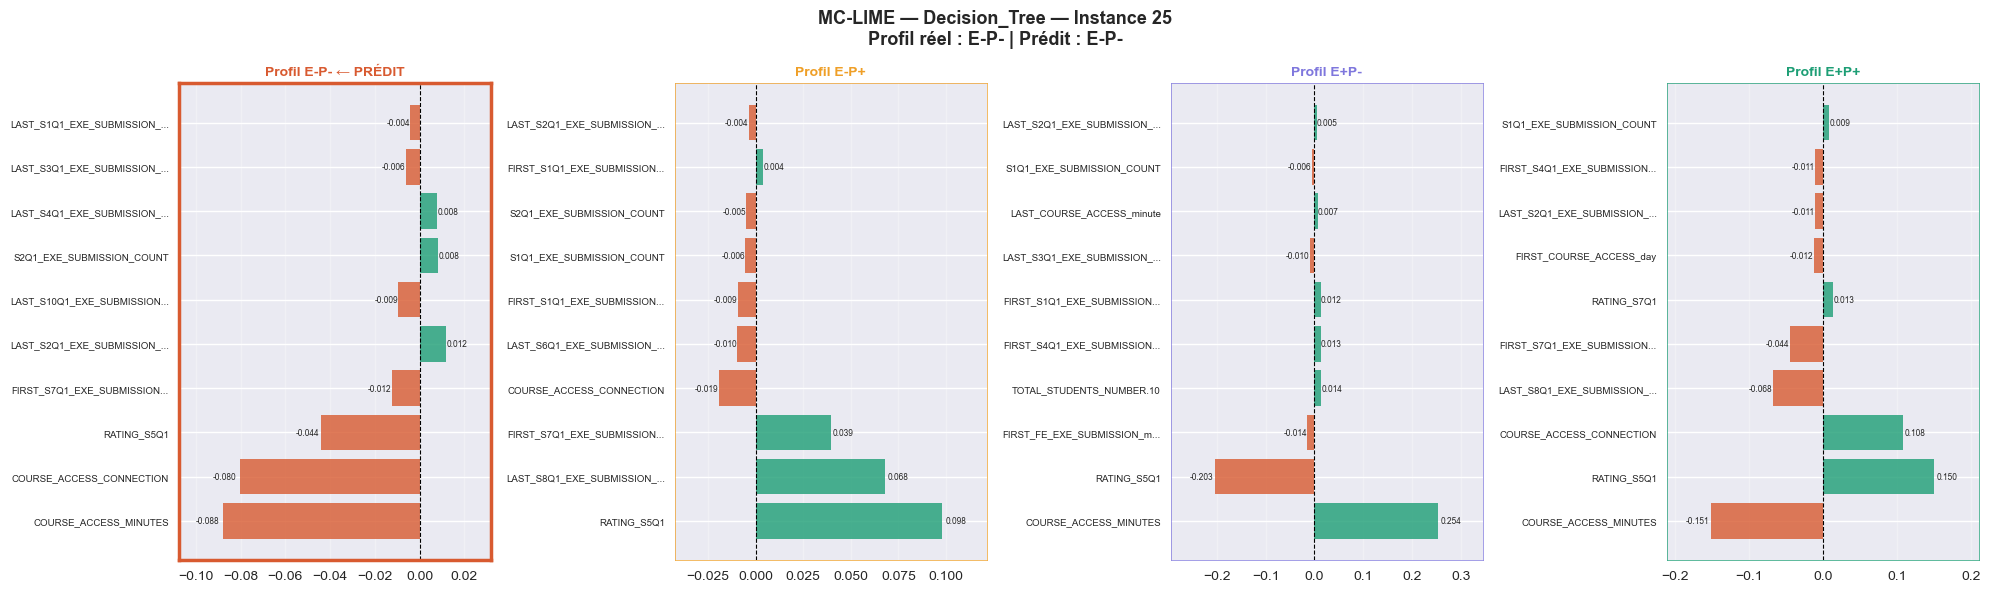

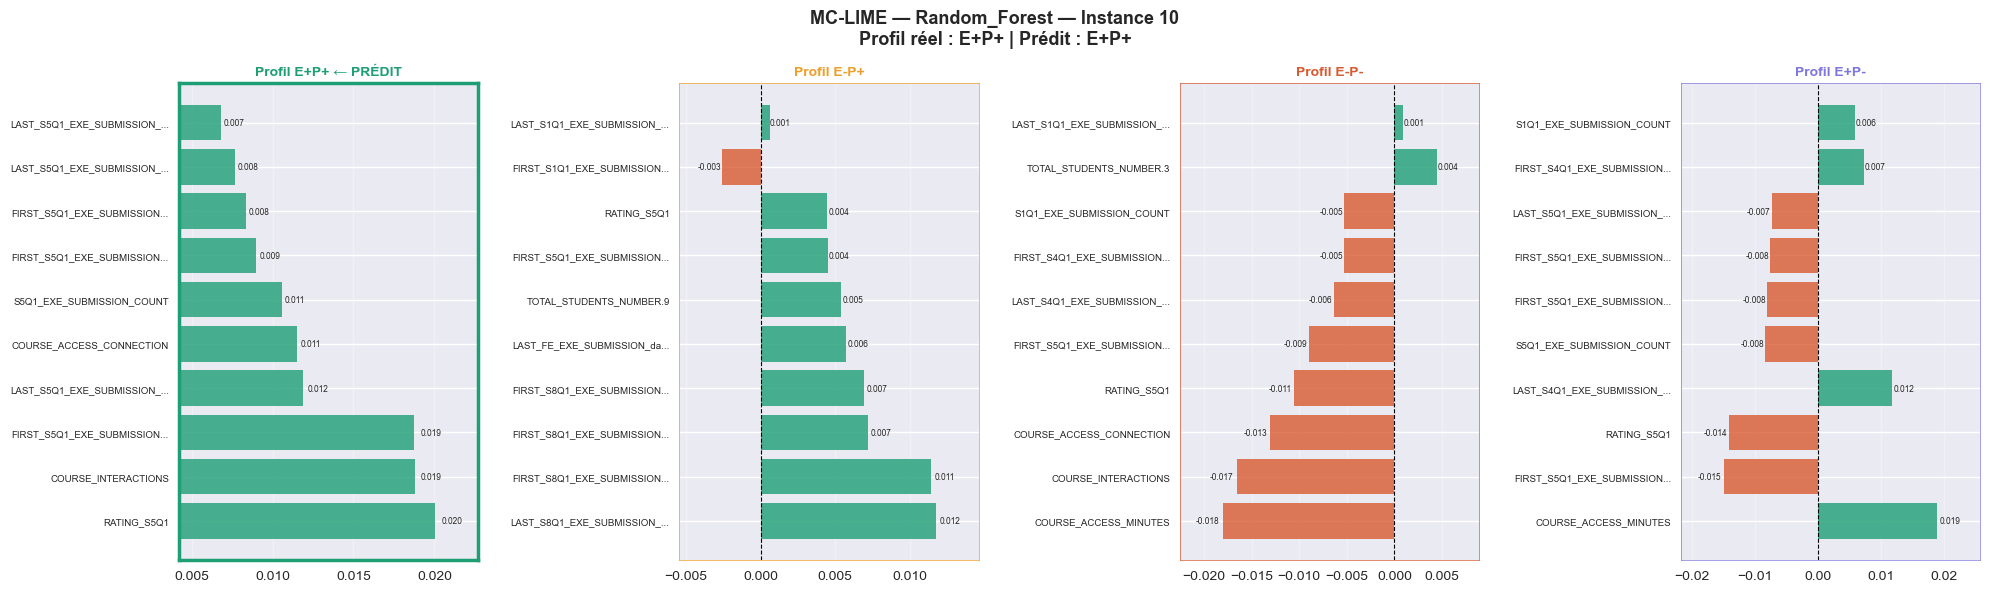

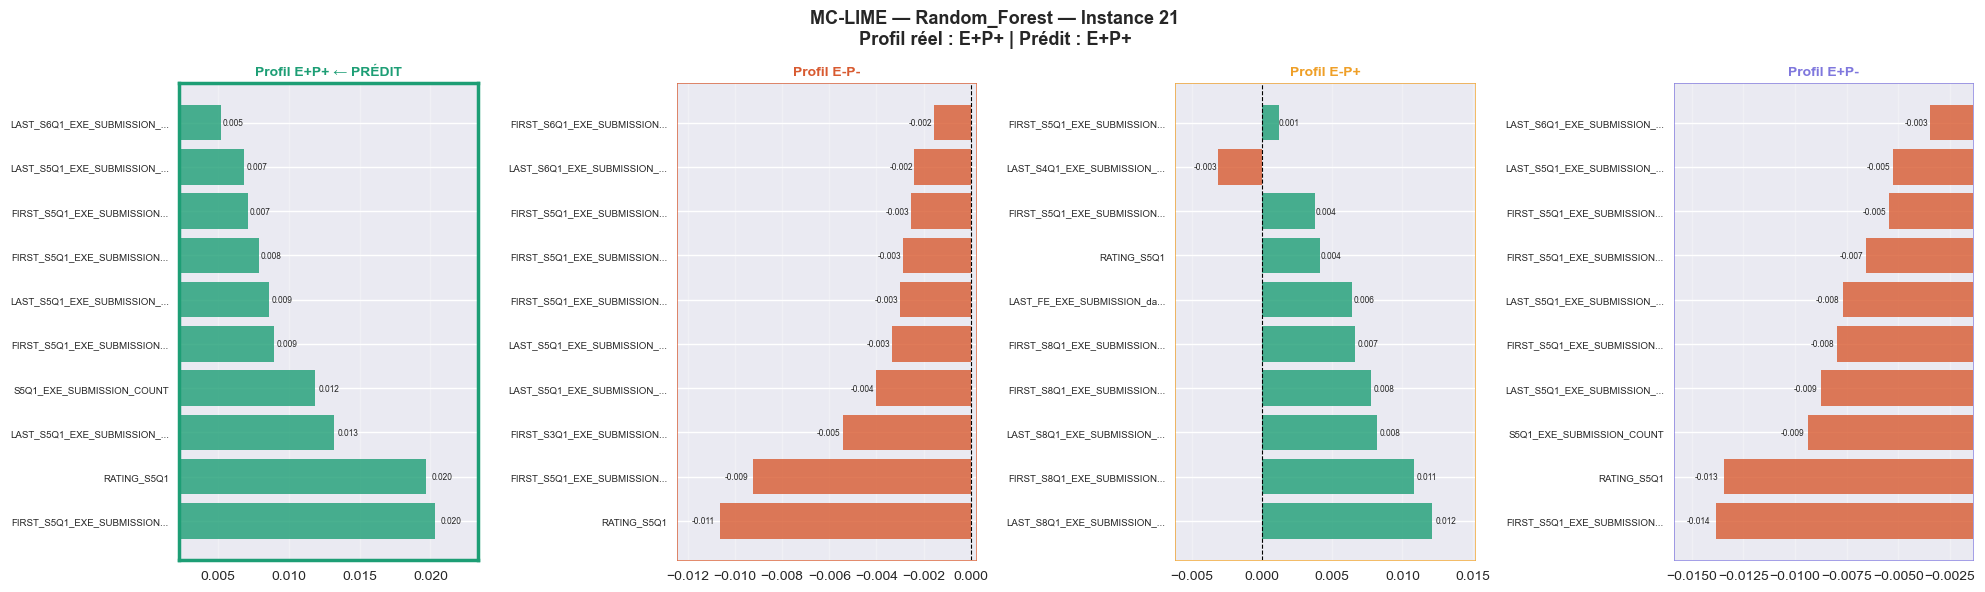

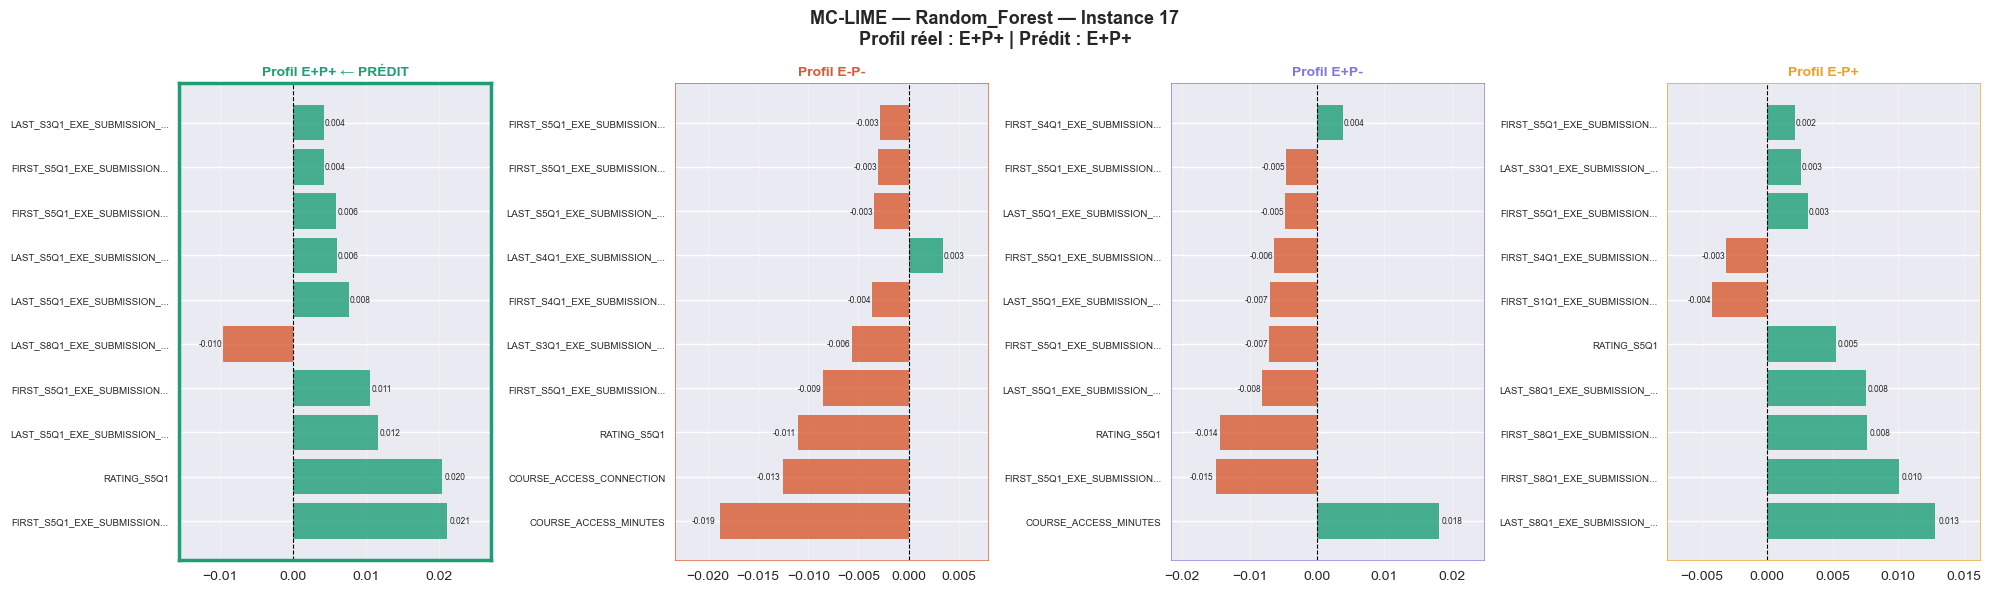

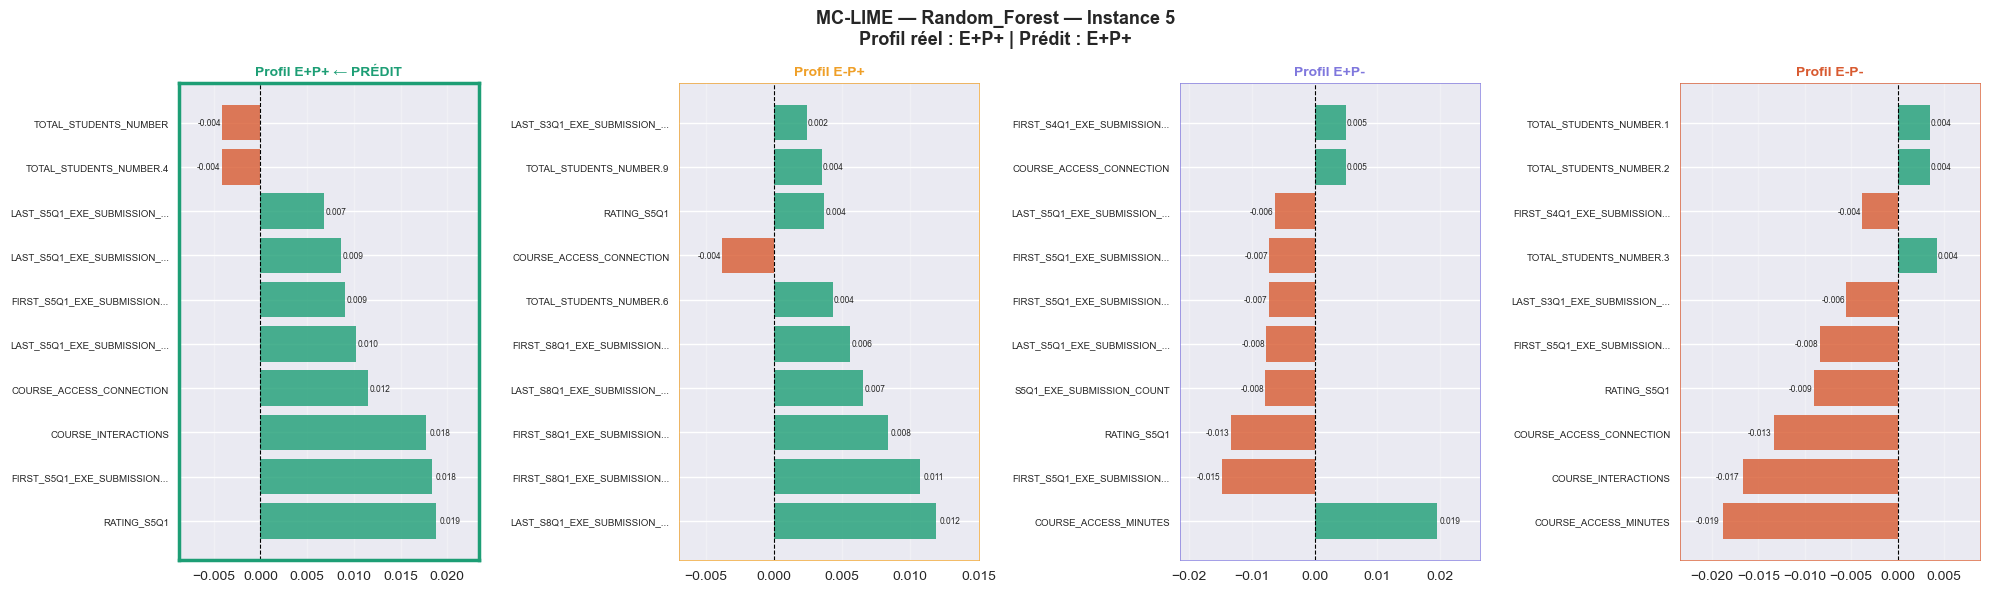

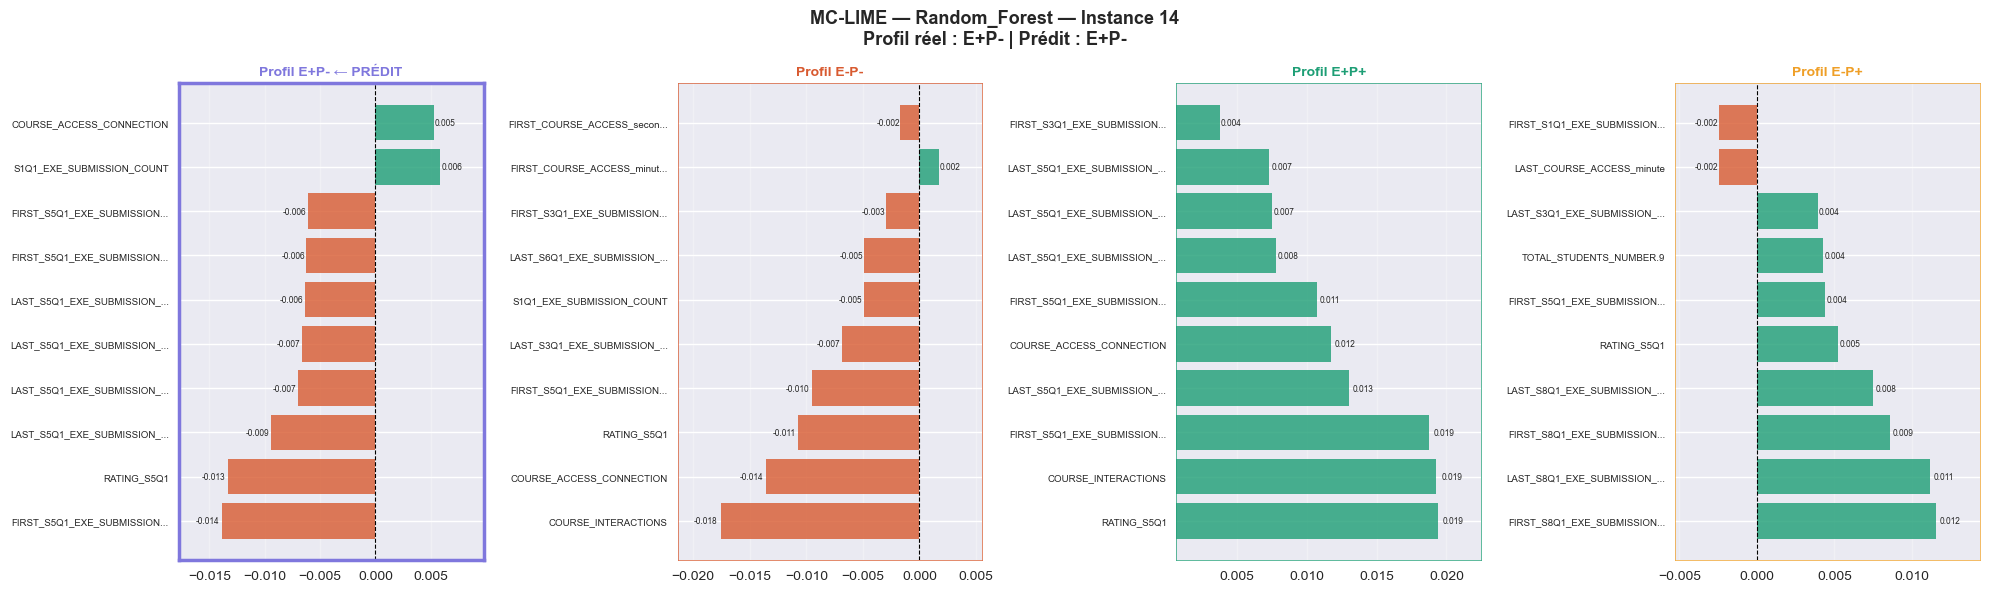

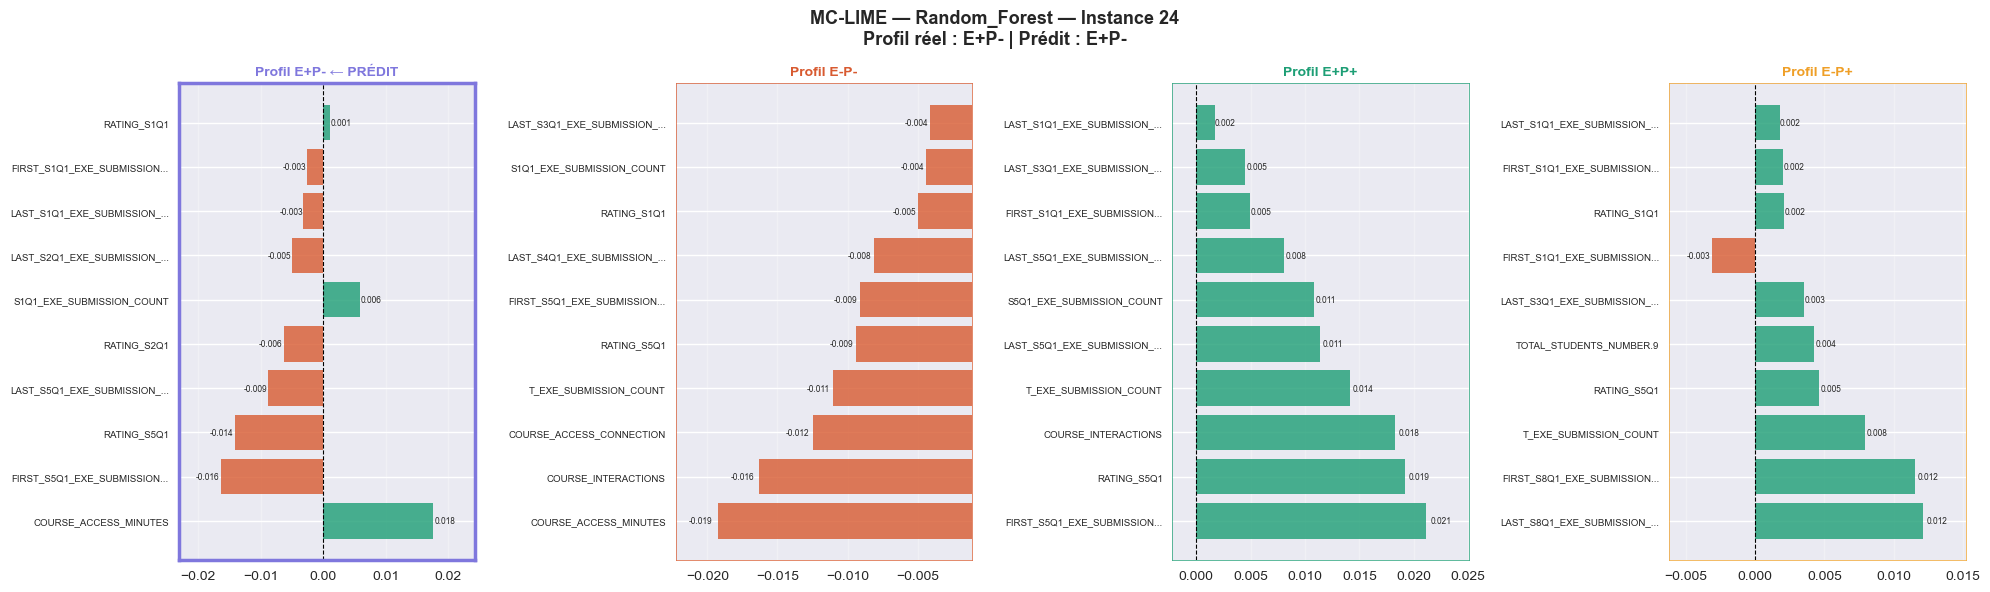

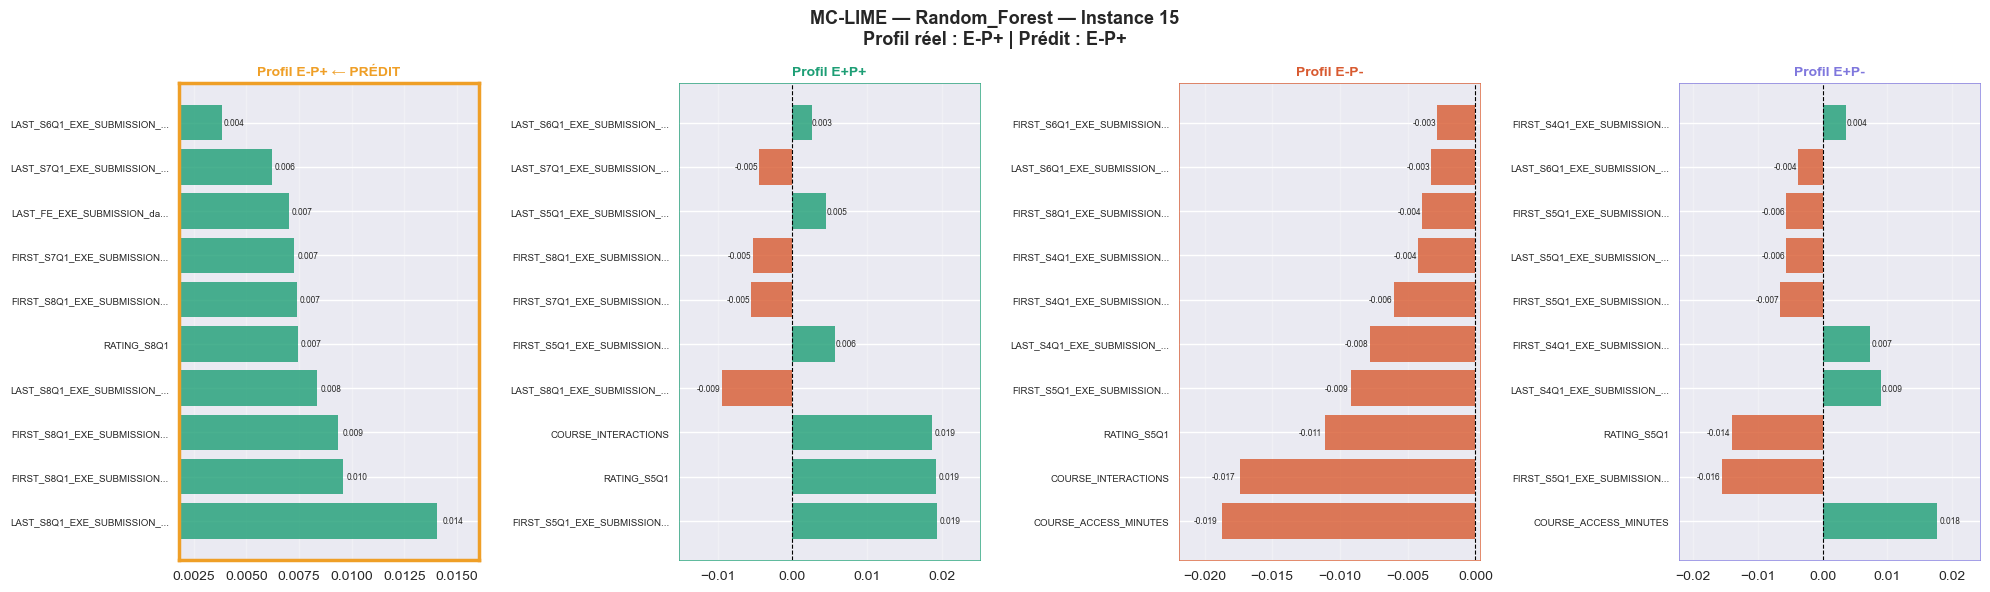

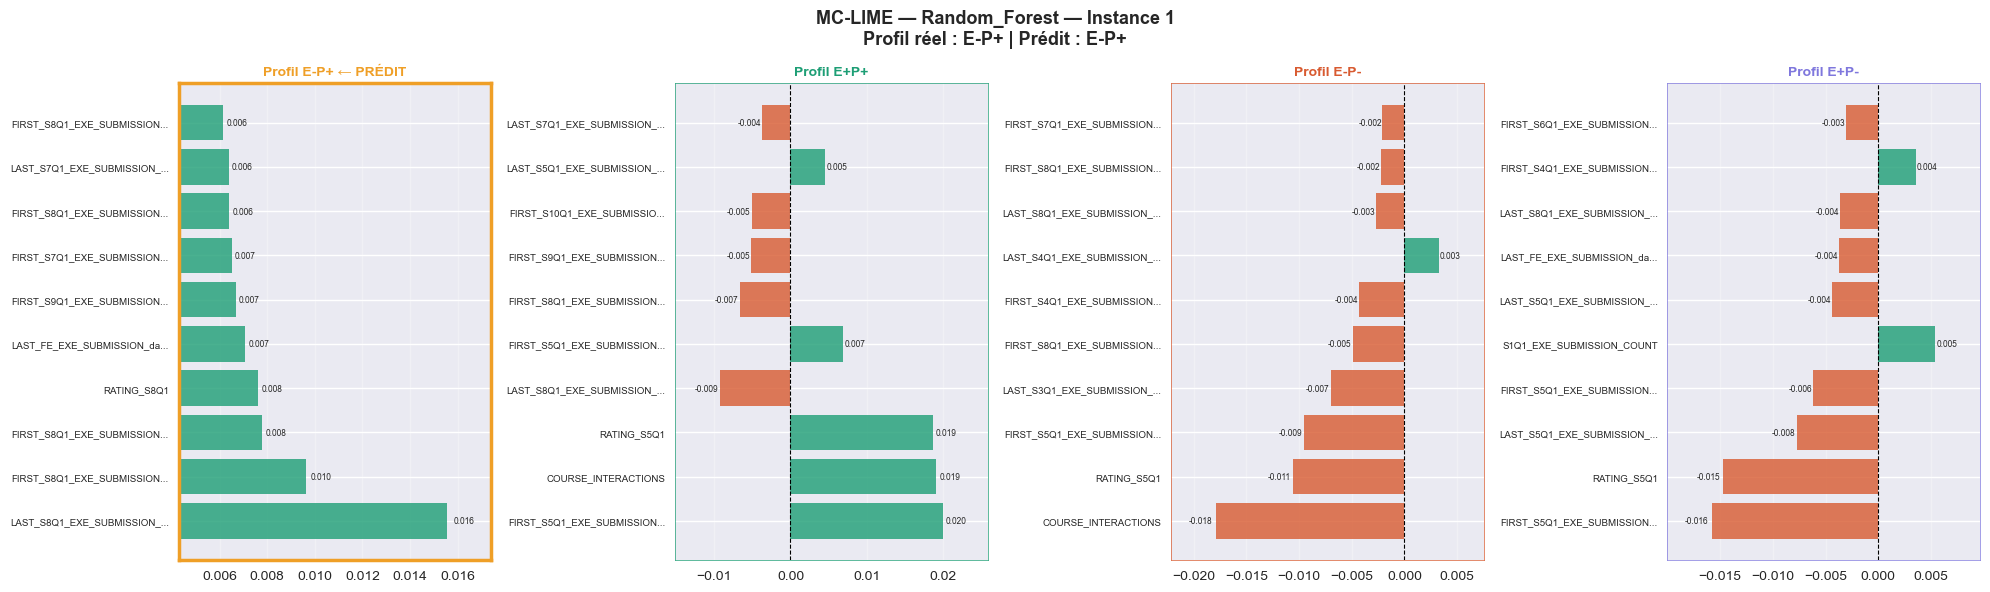

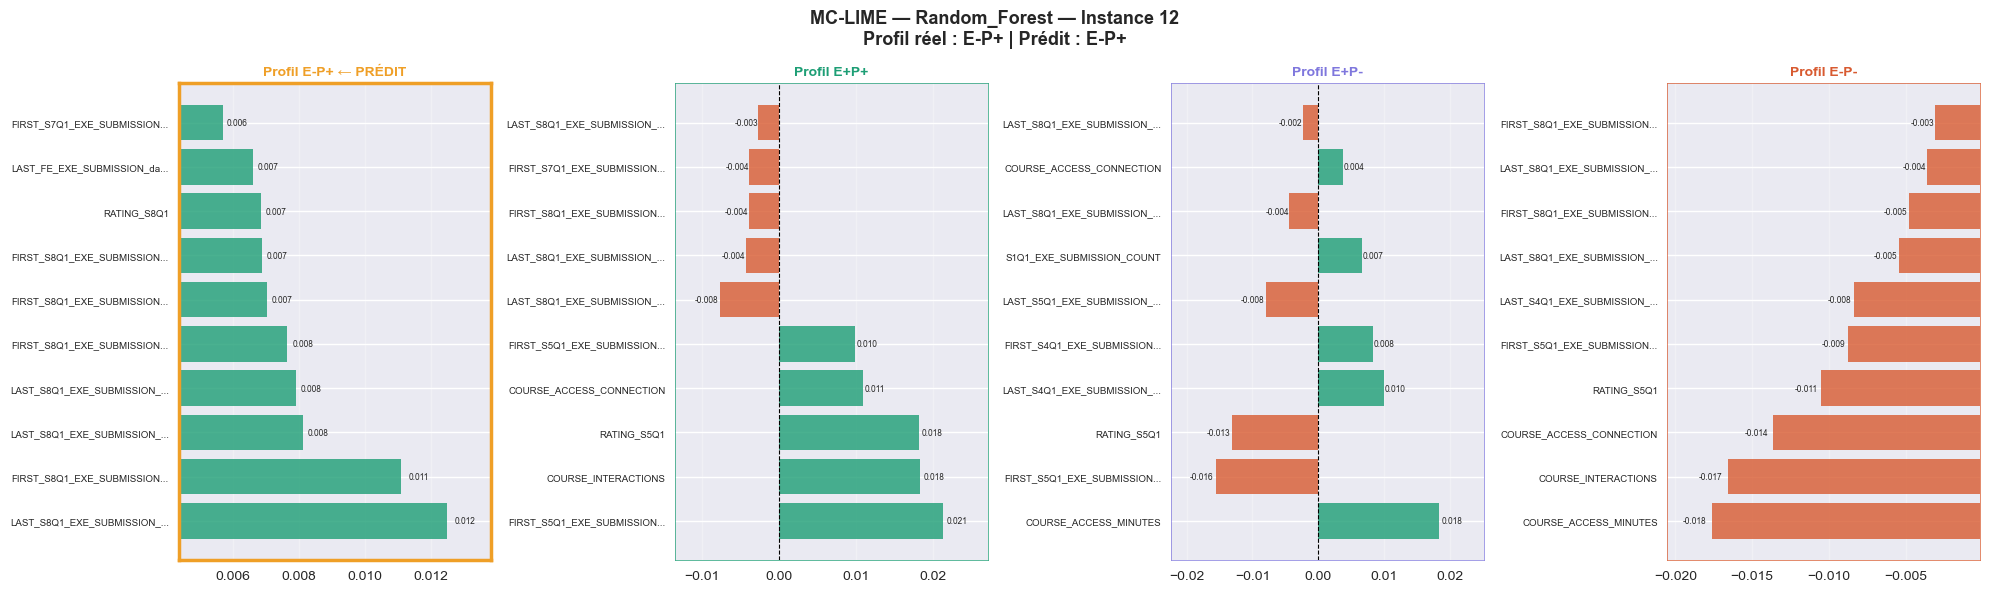

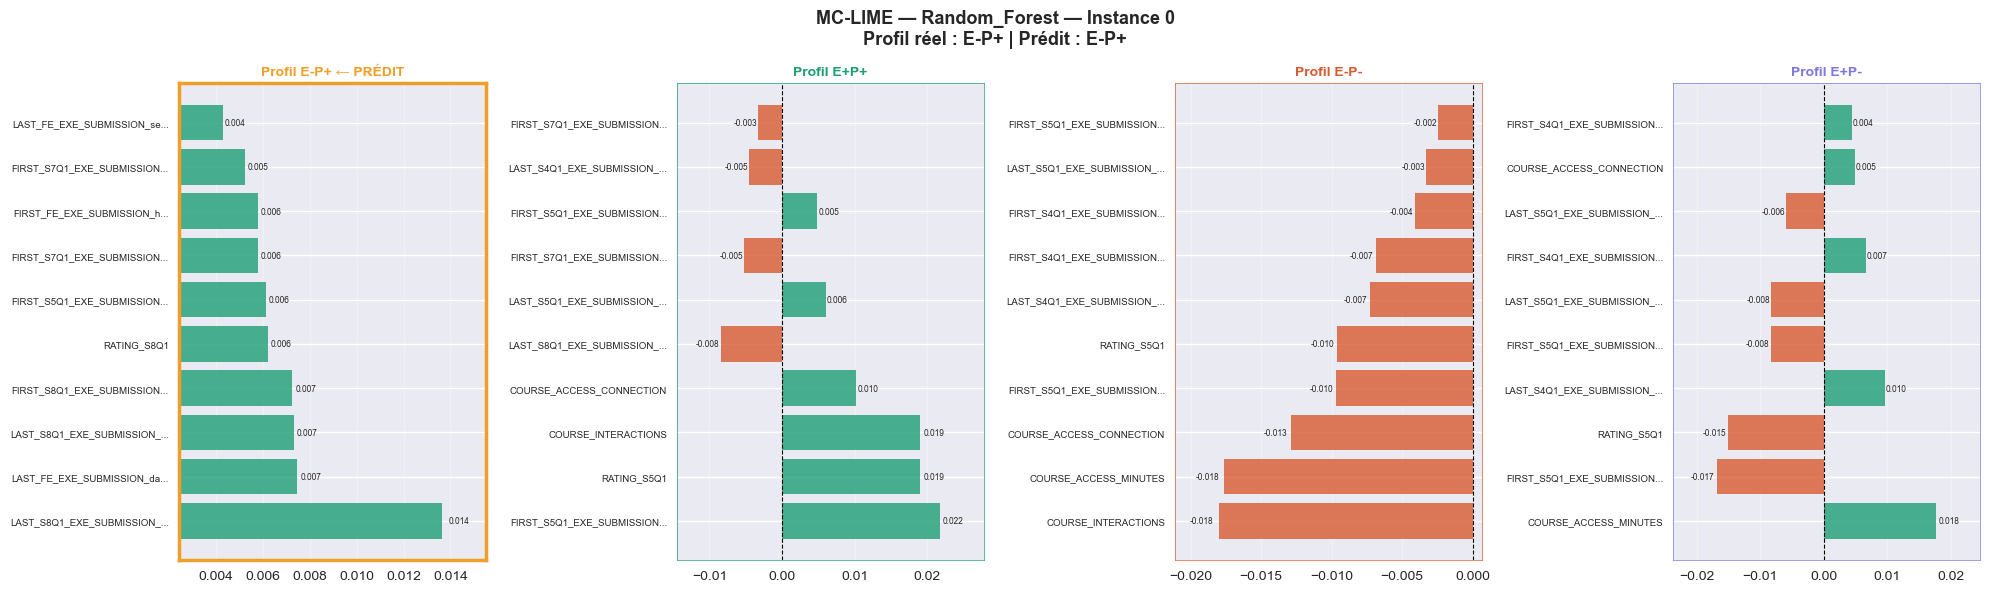

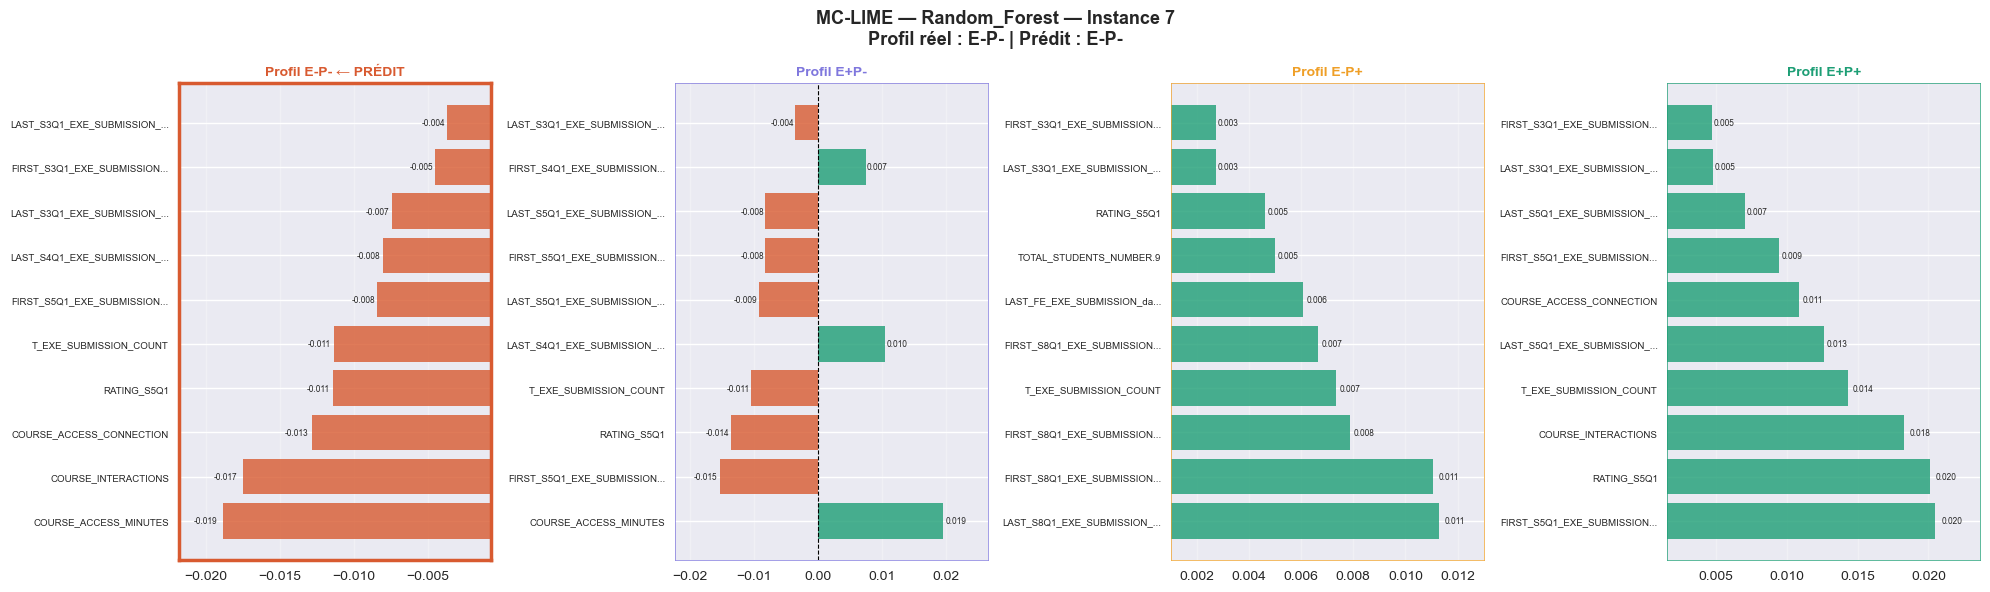

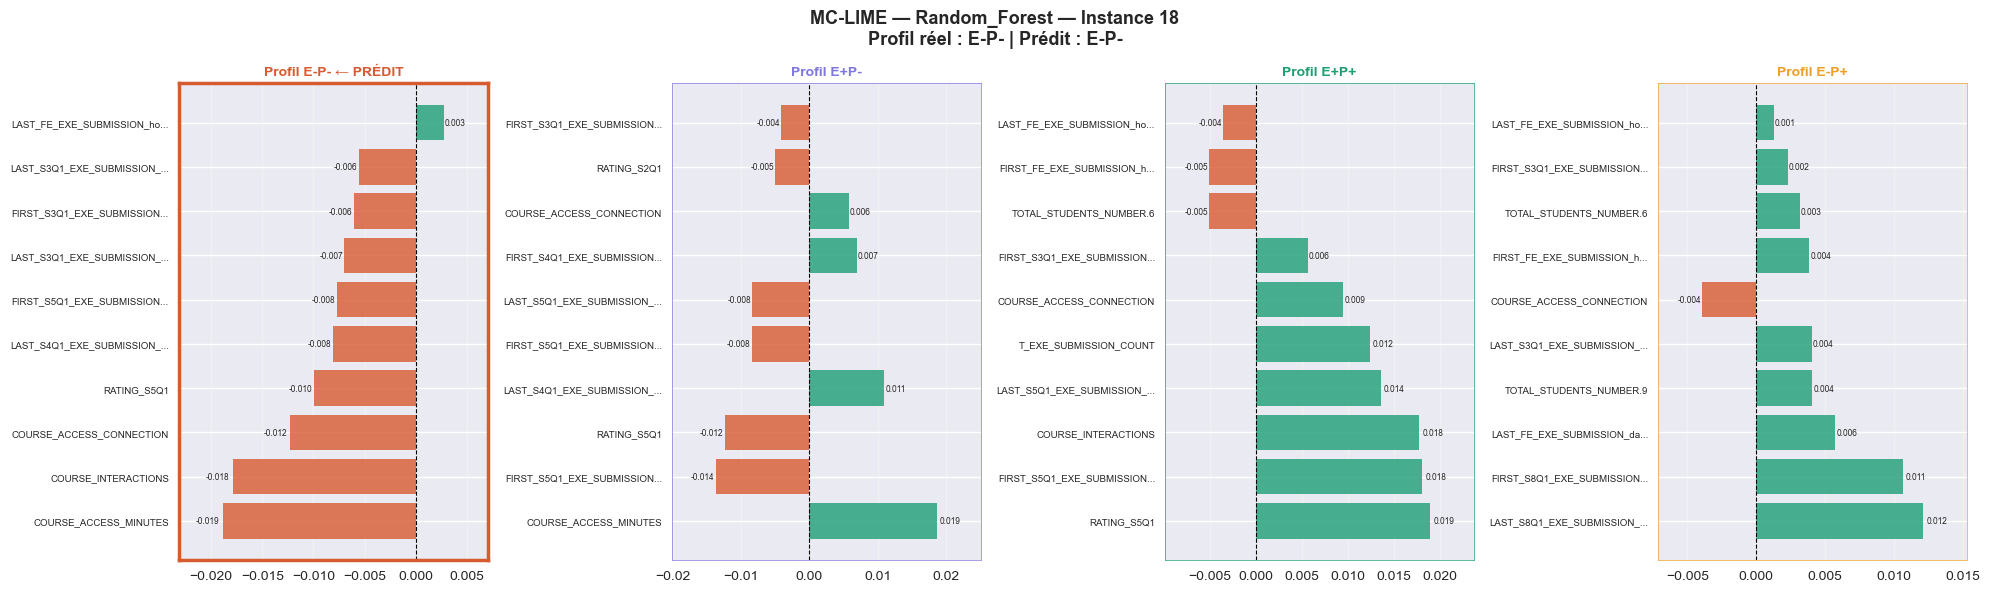

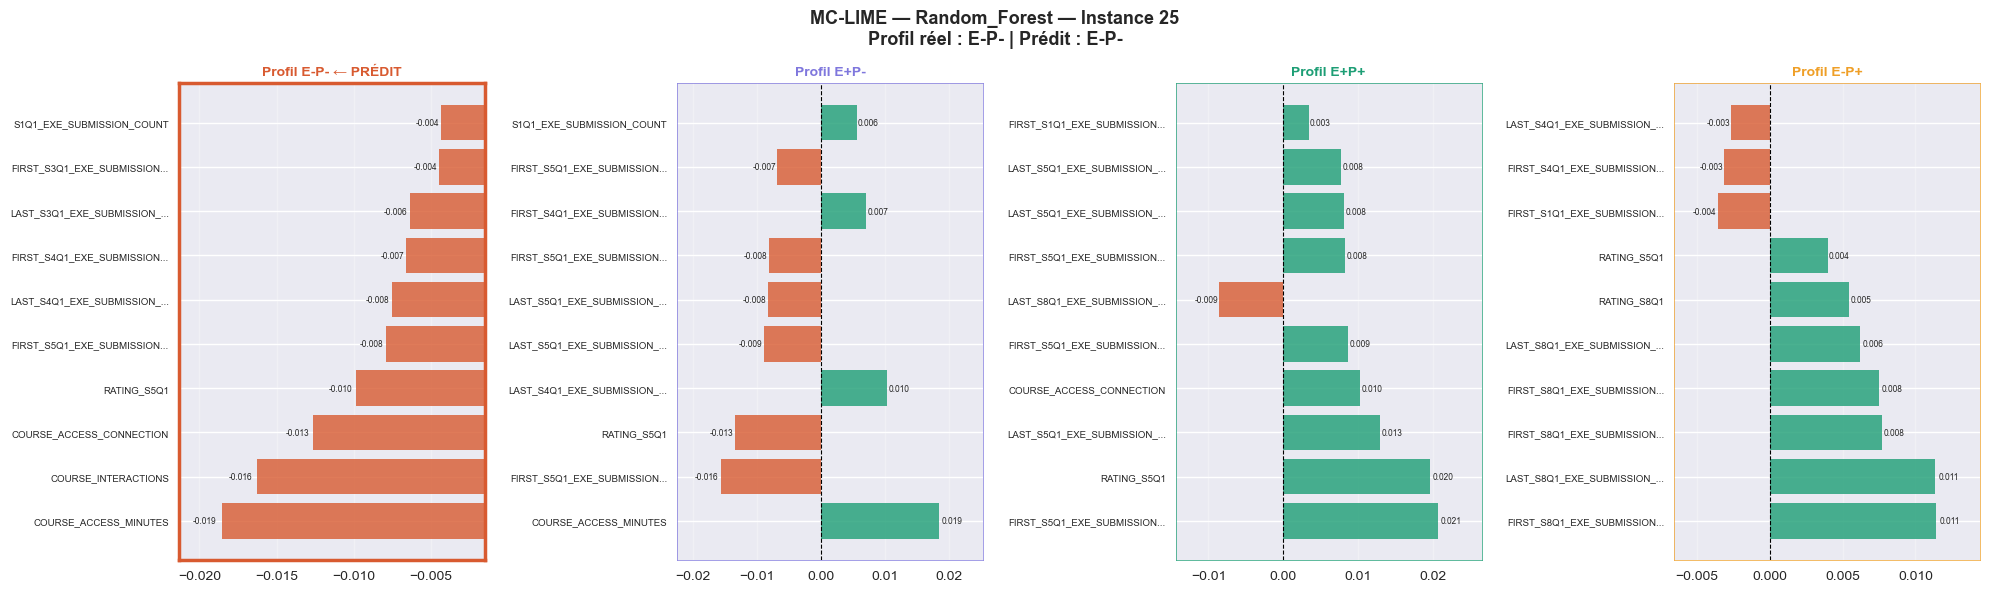

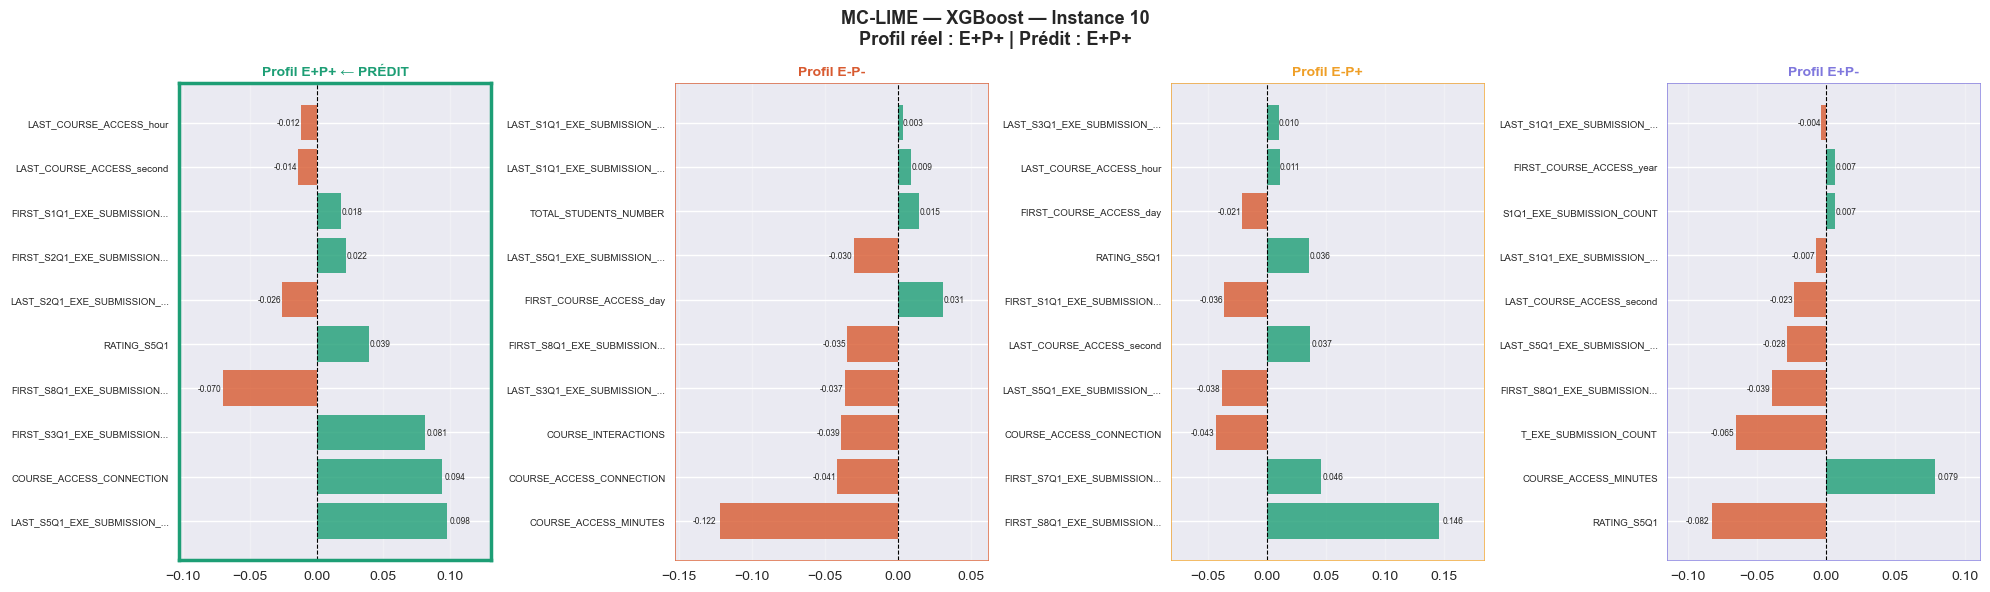

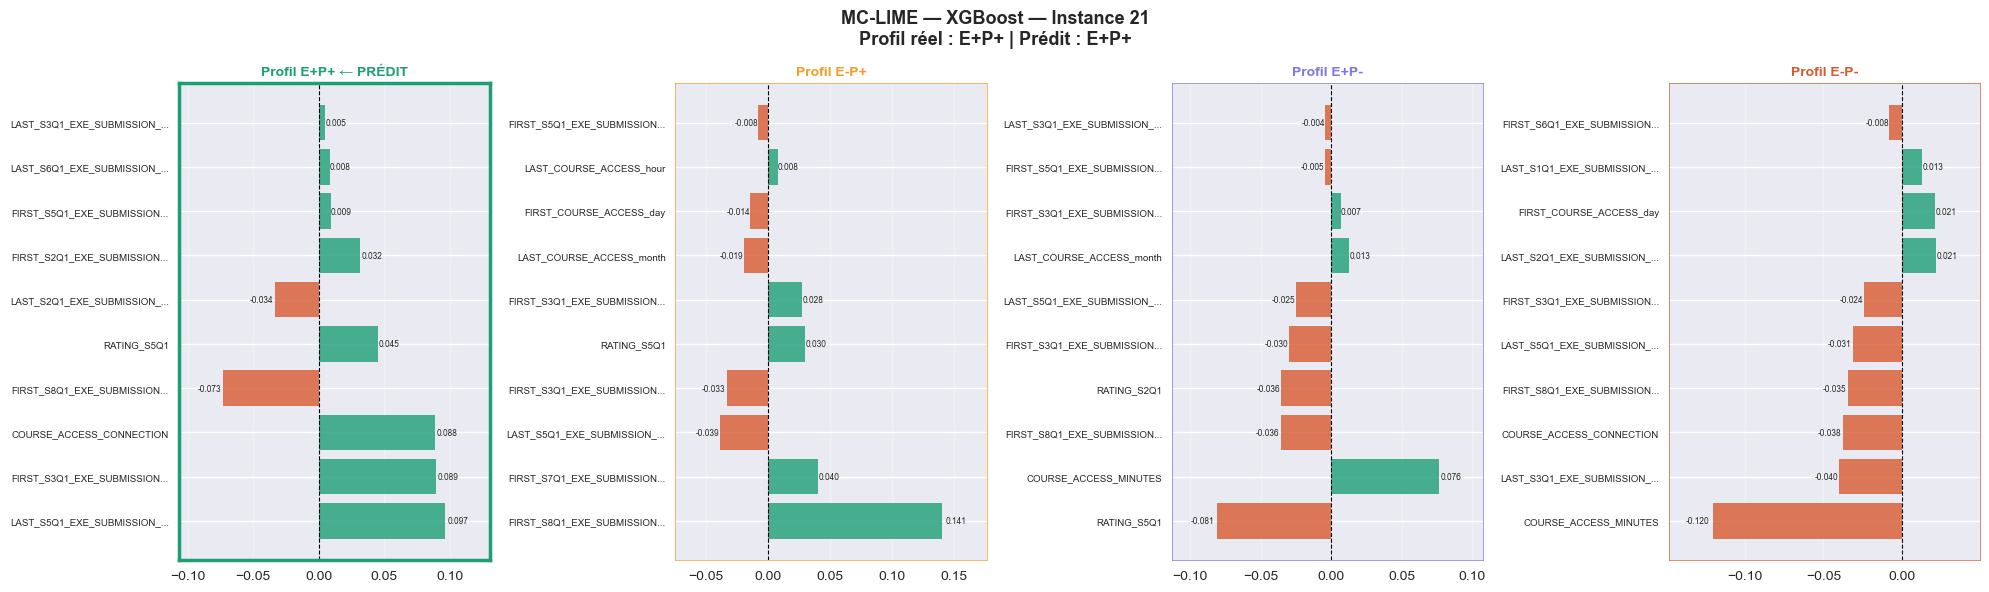

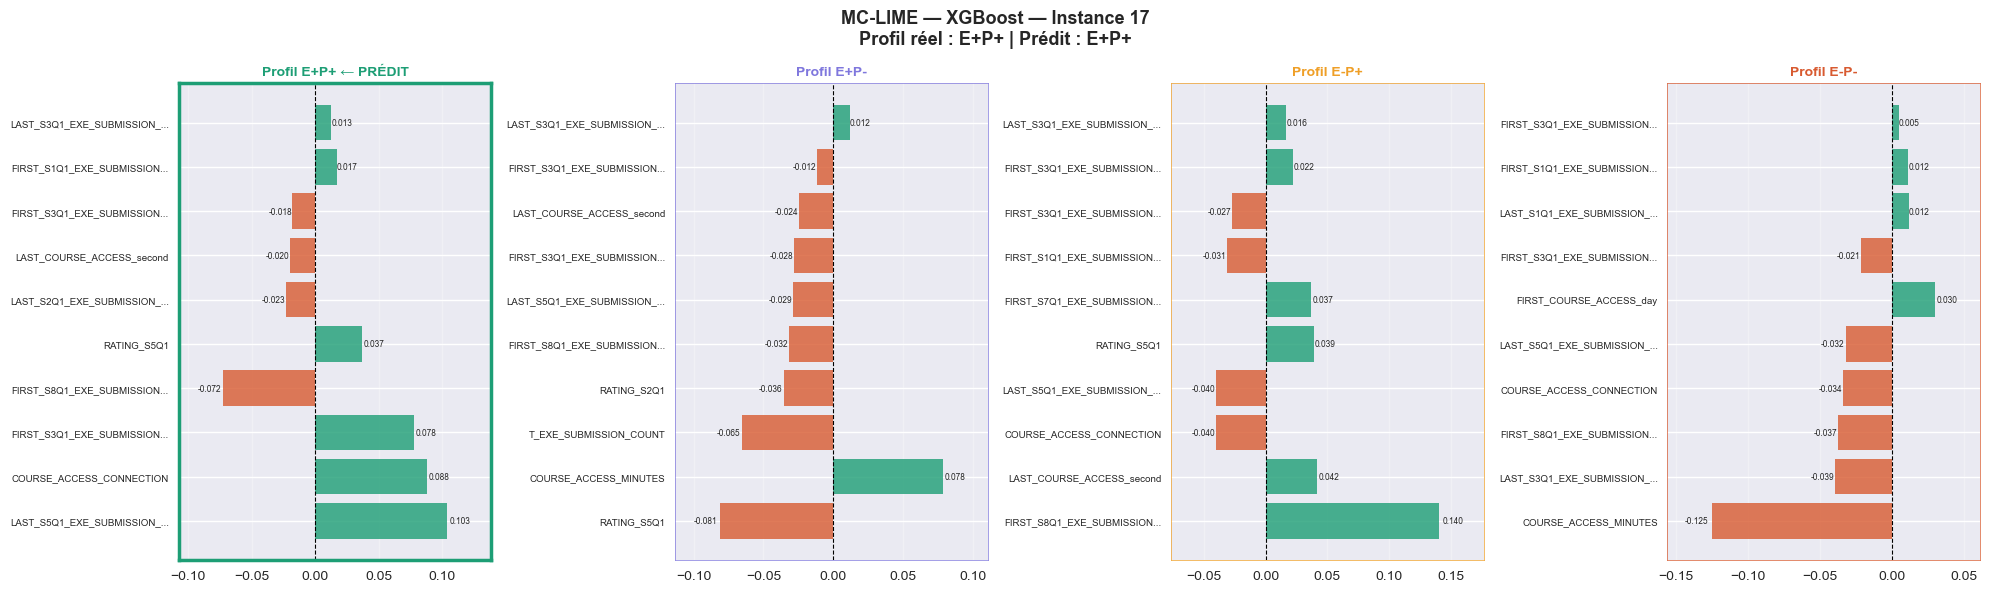

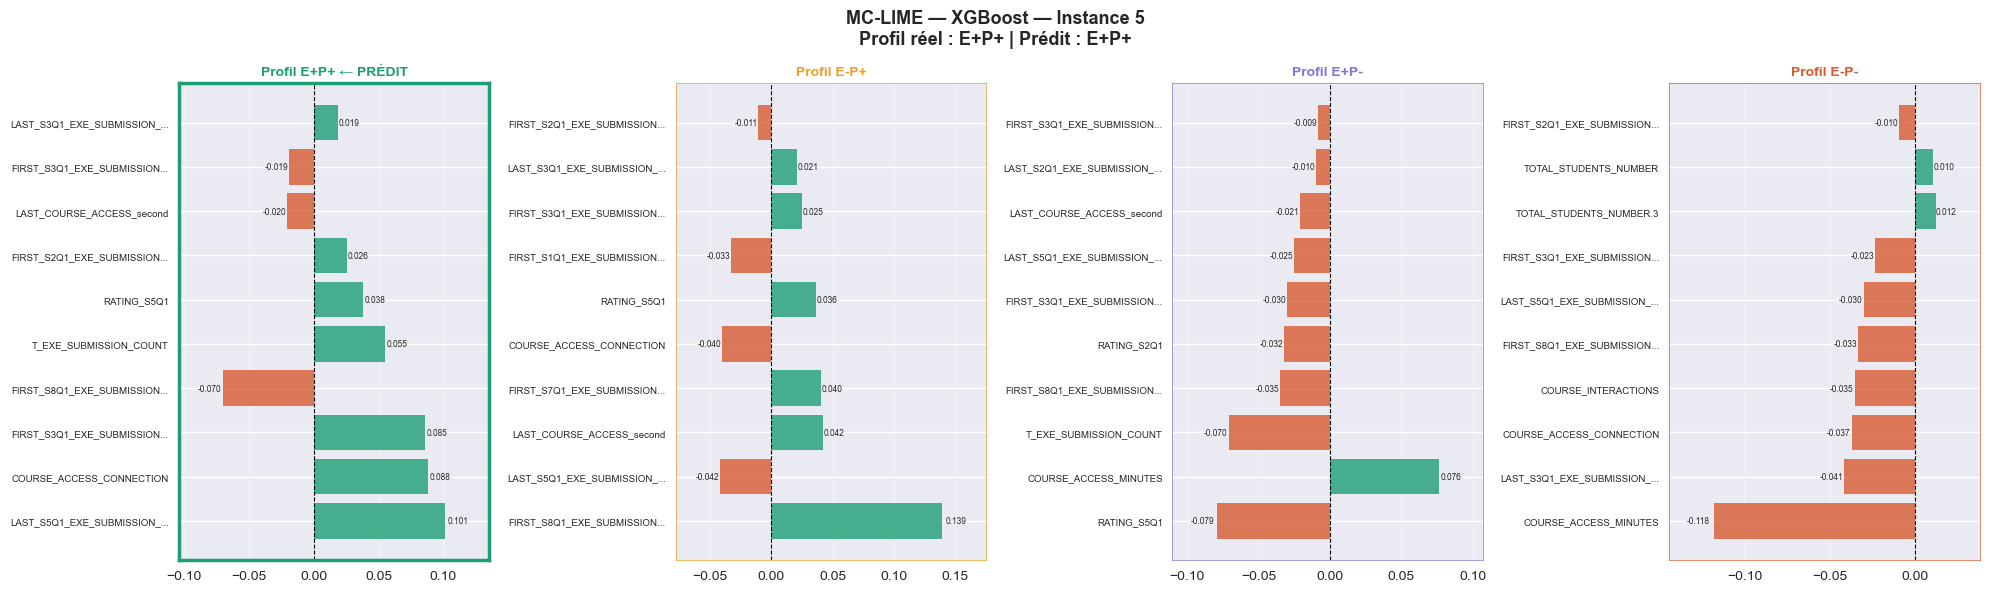

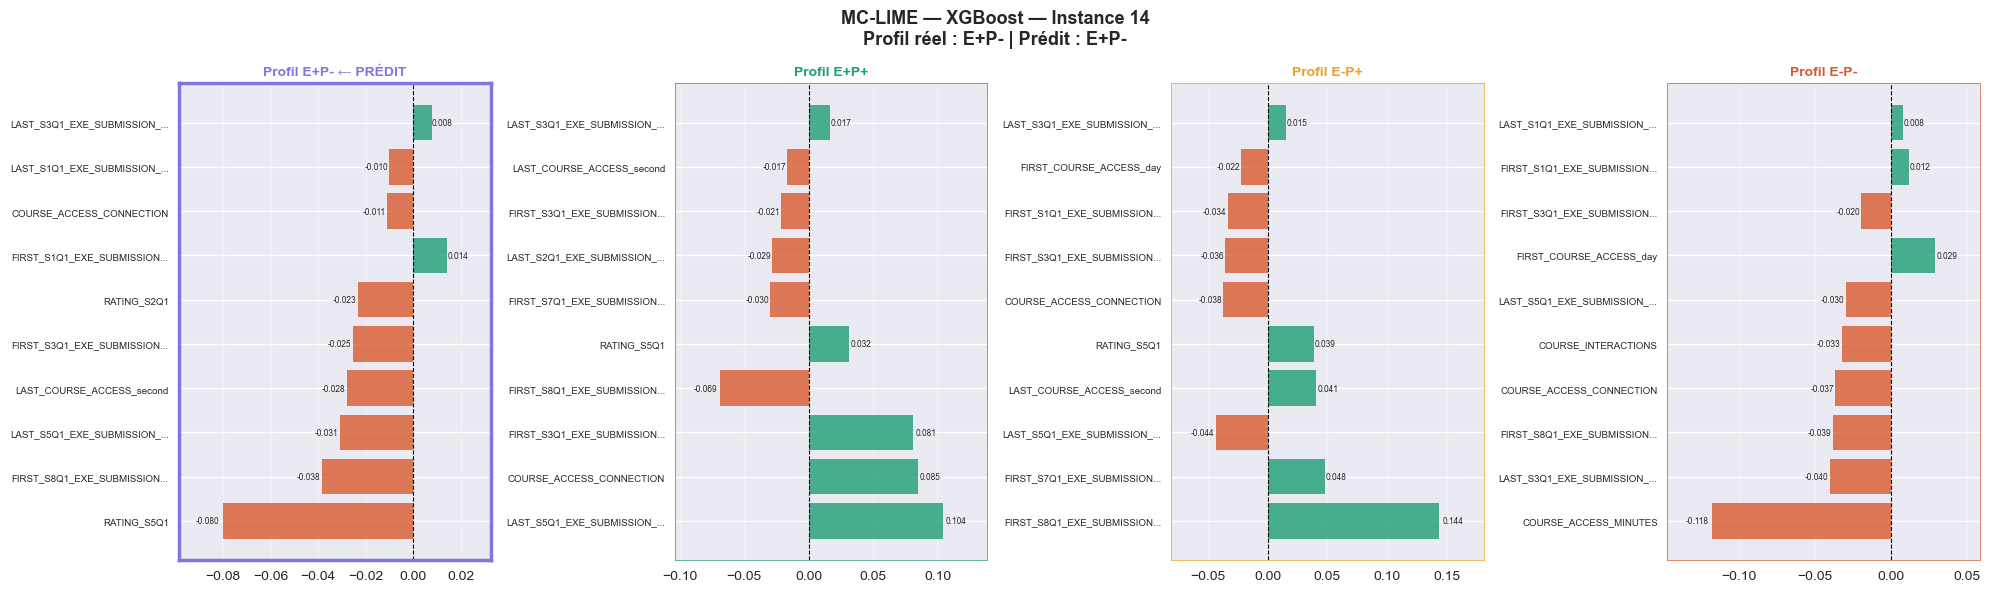

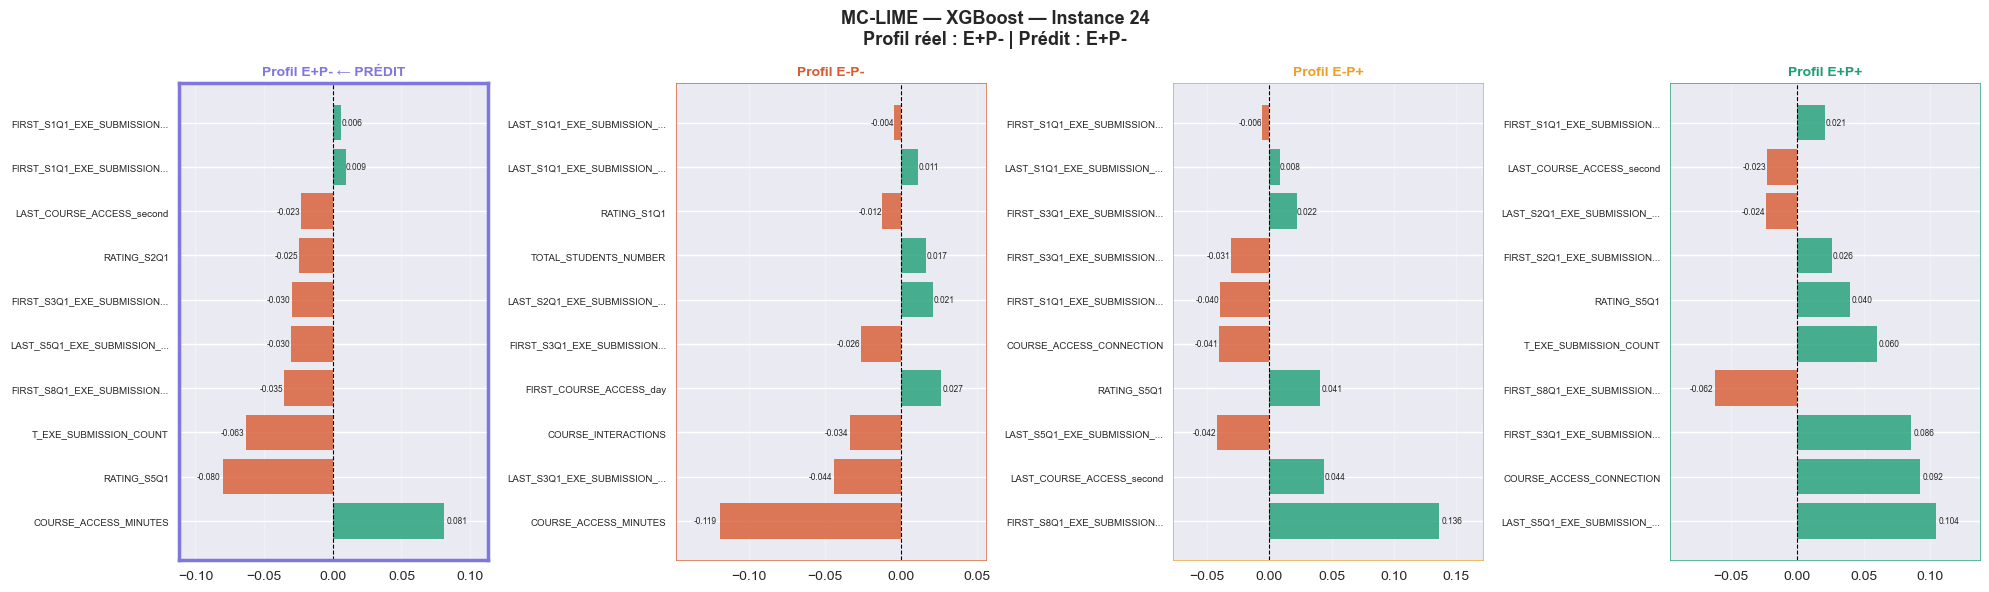

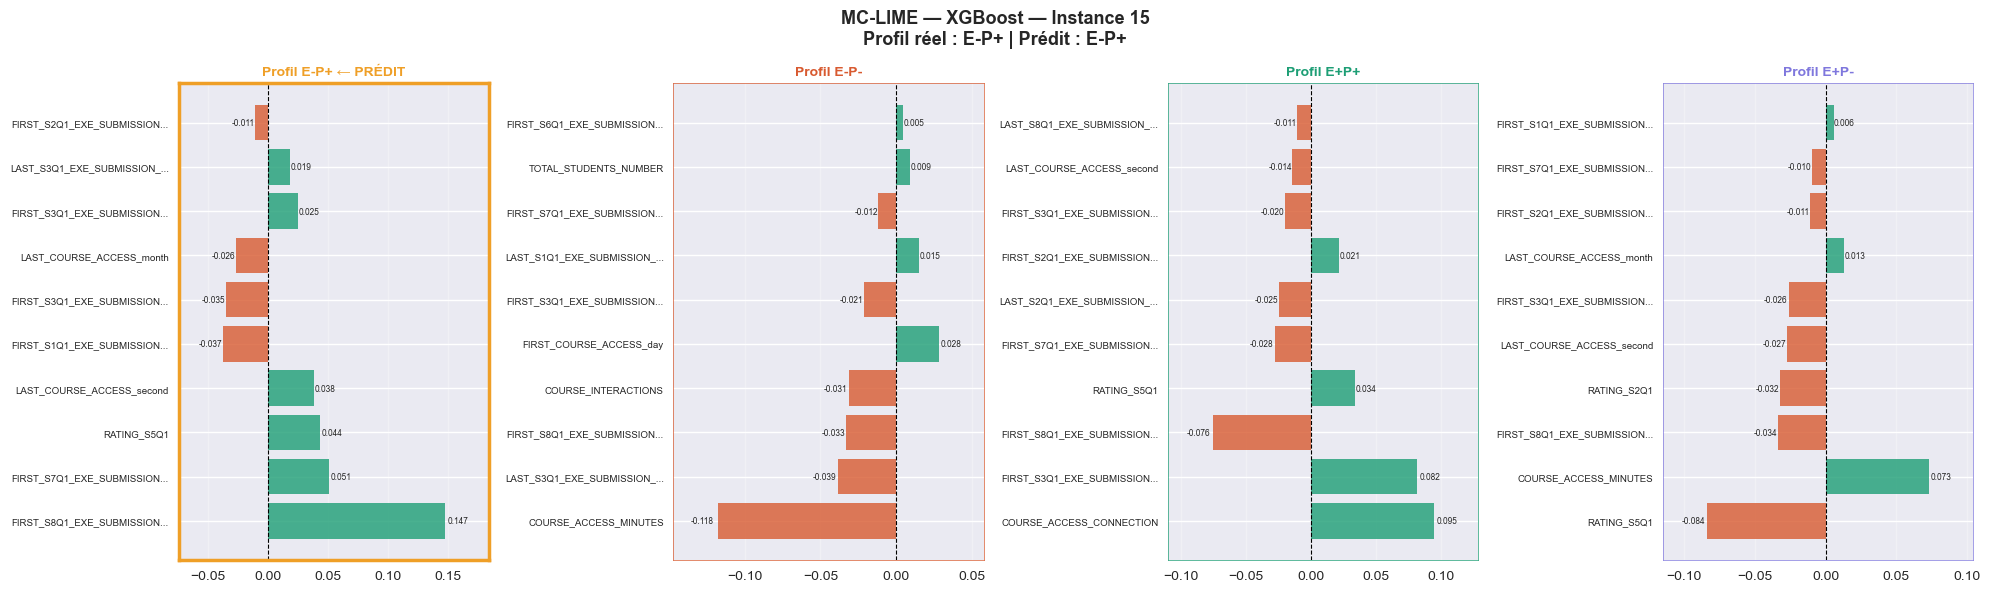

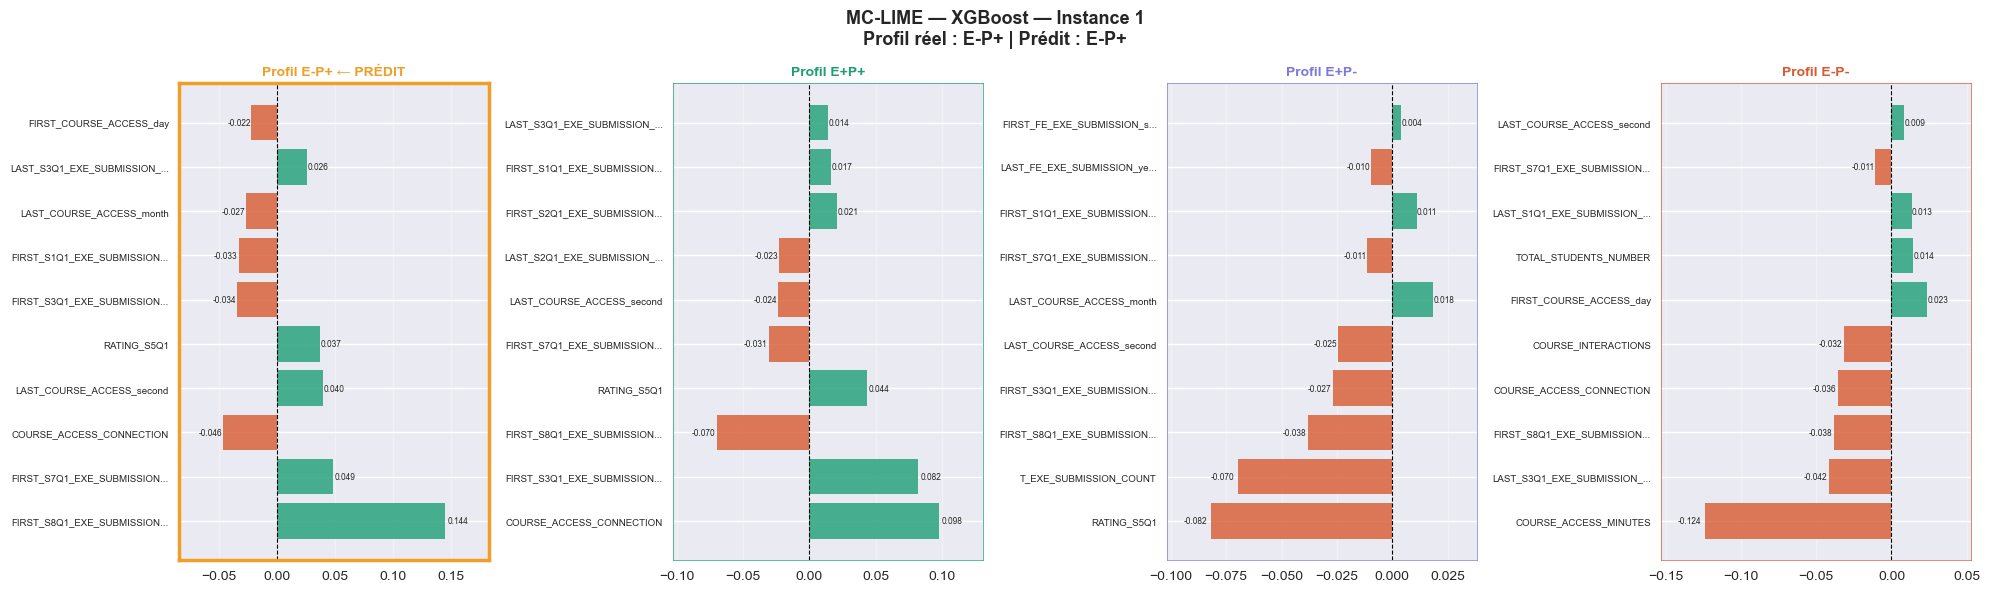

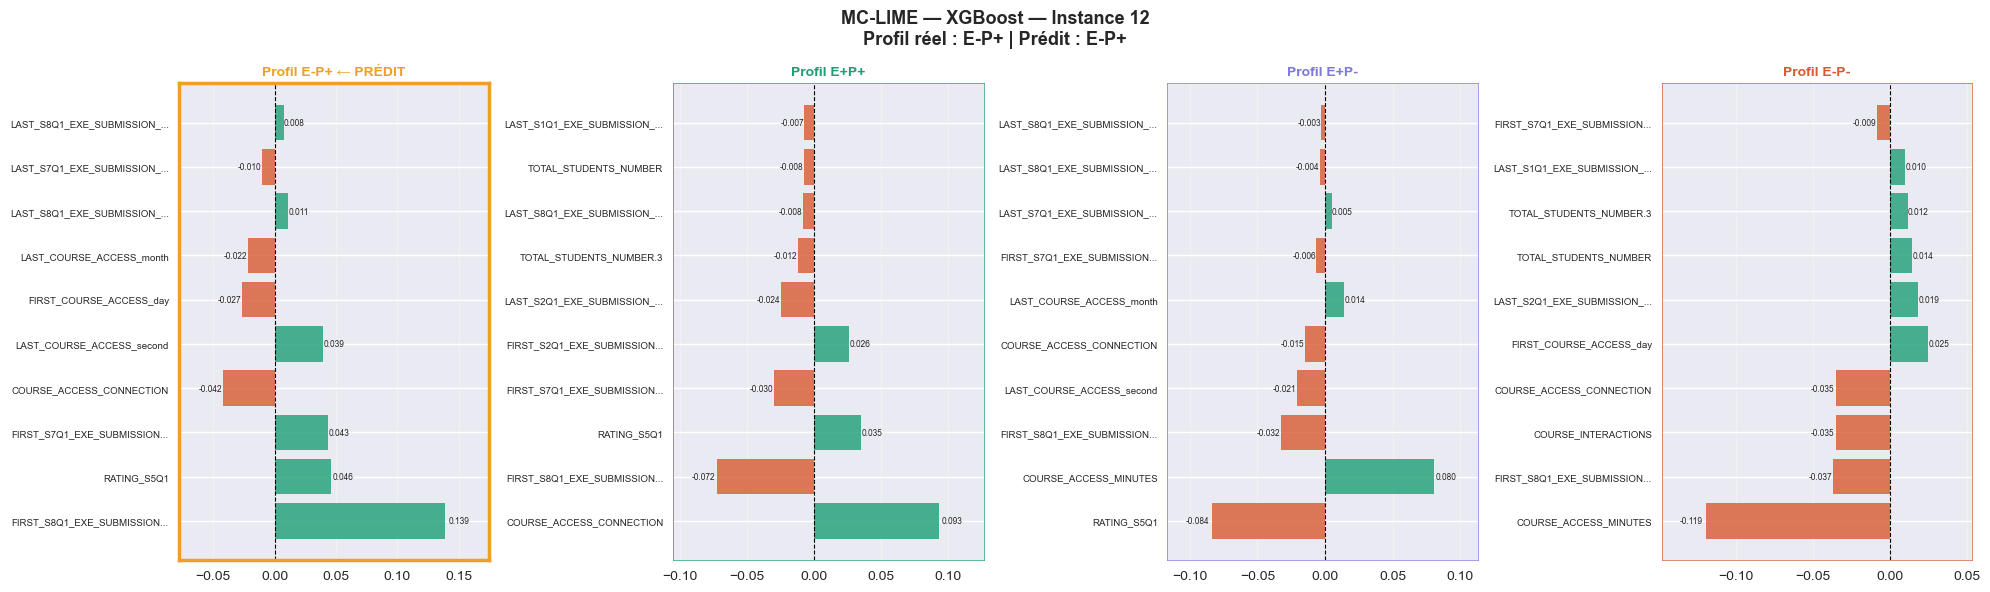

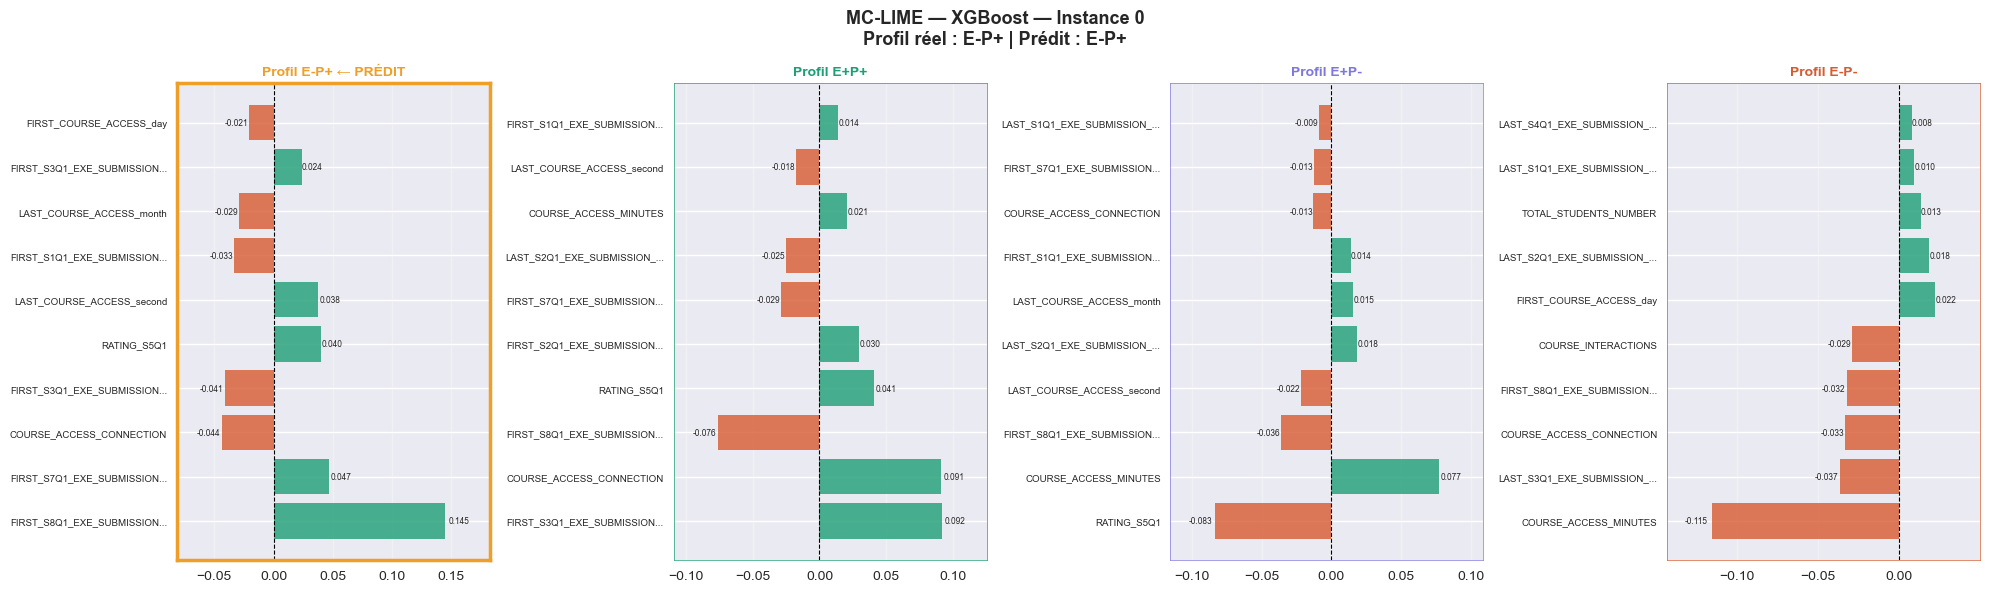

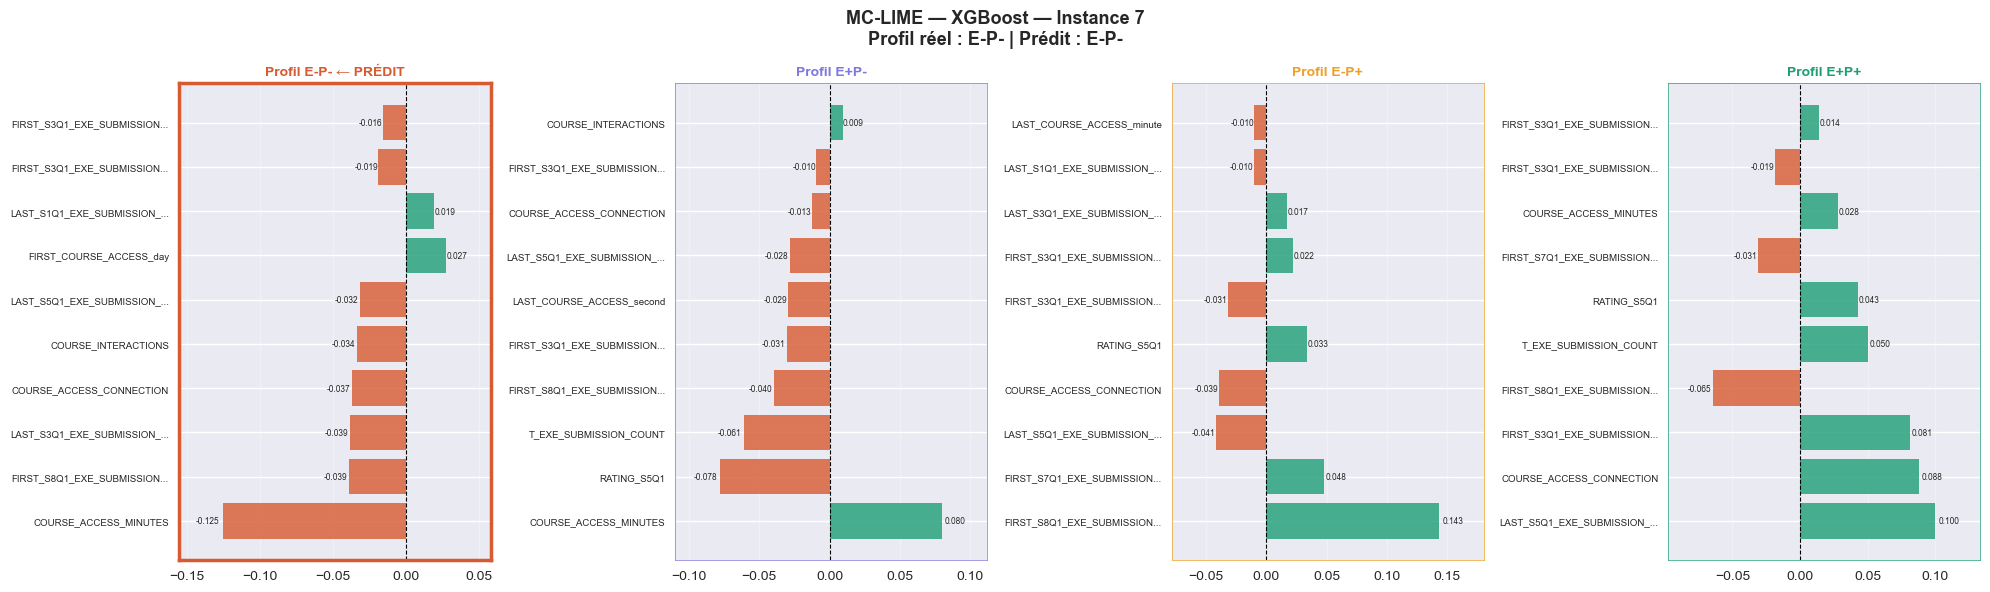

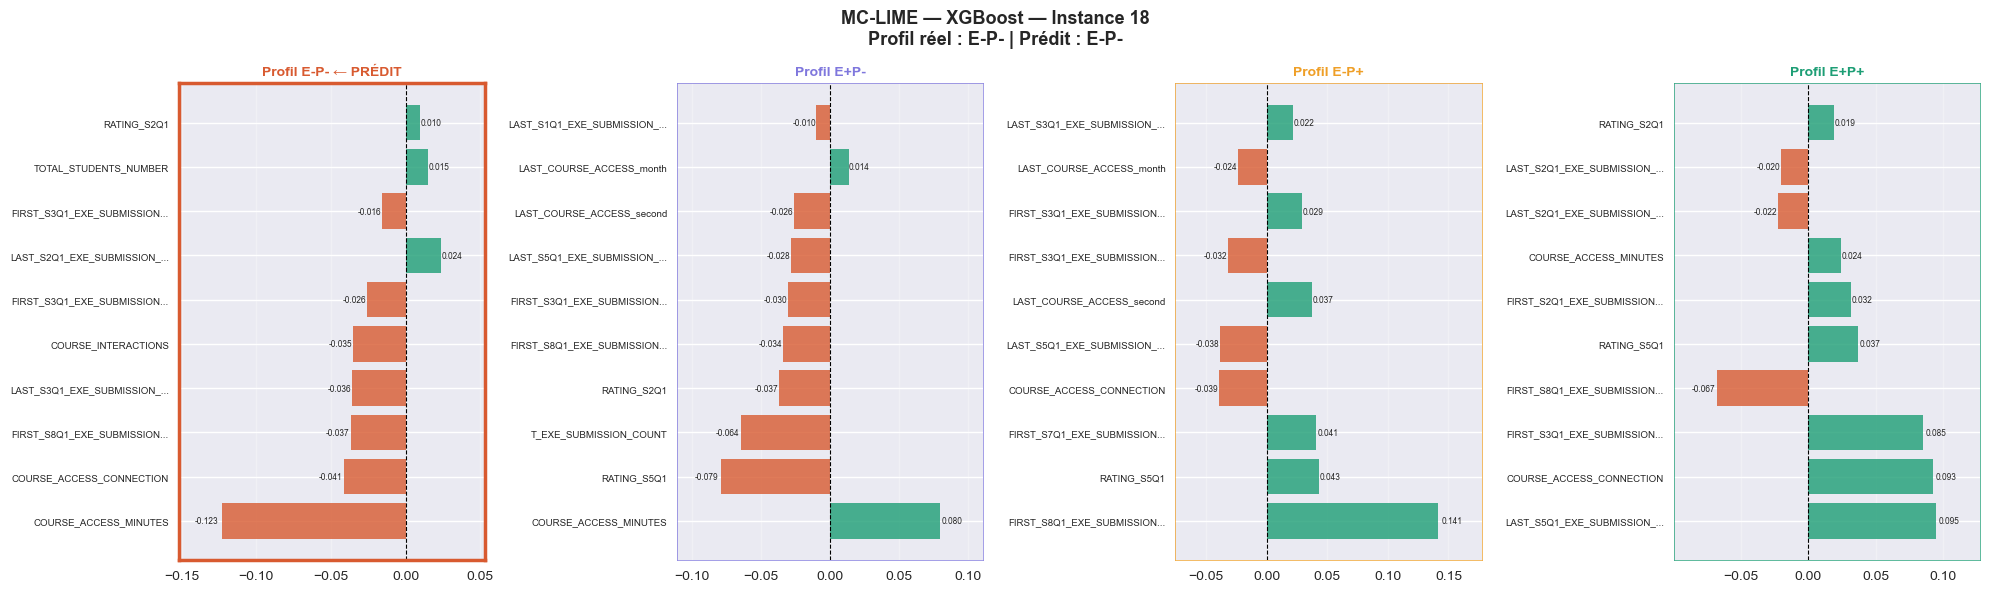

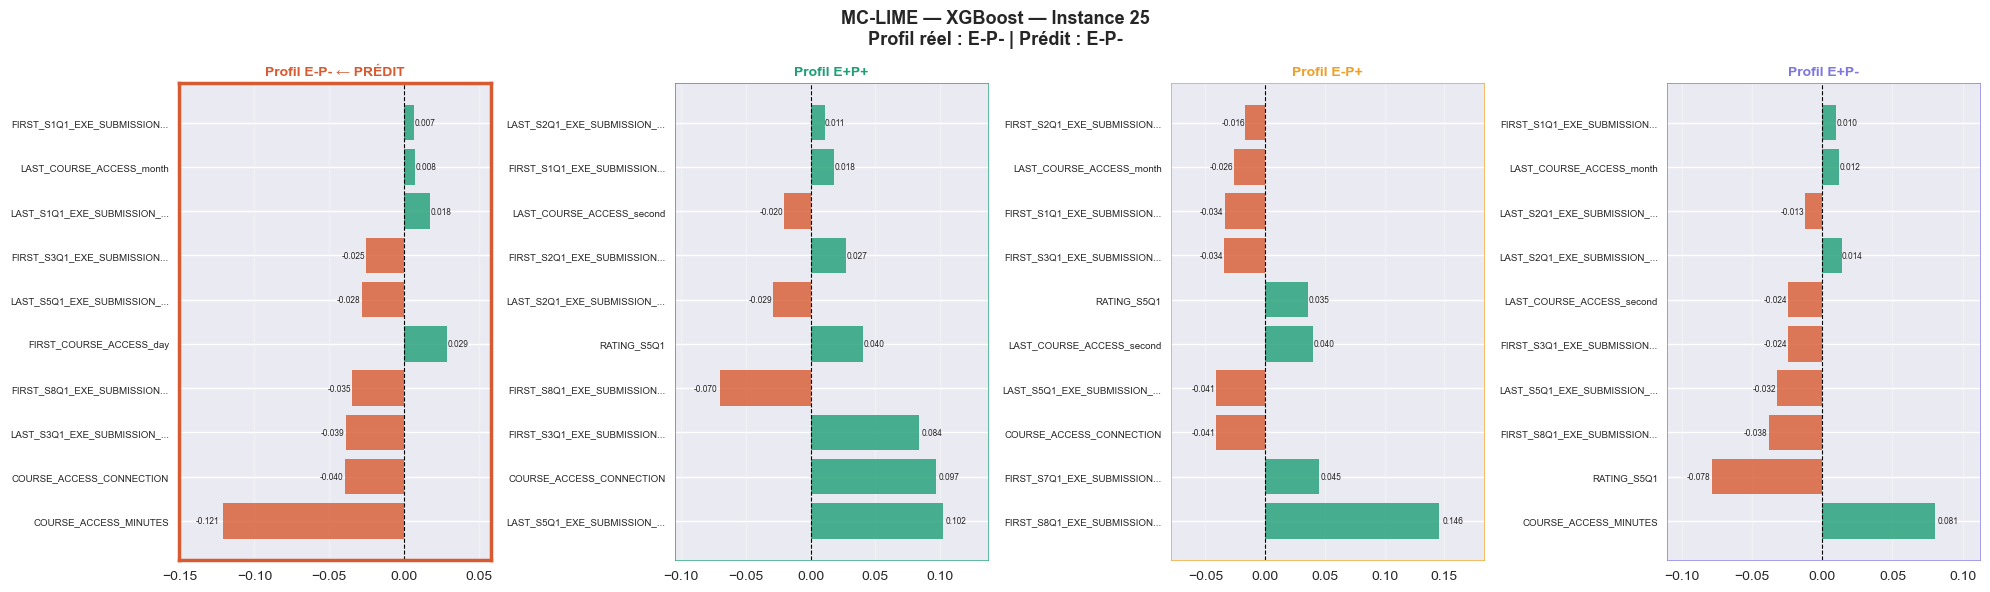


📊 HEATMAP : contributions moyennes par profil


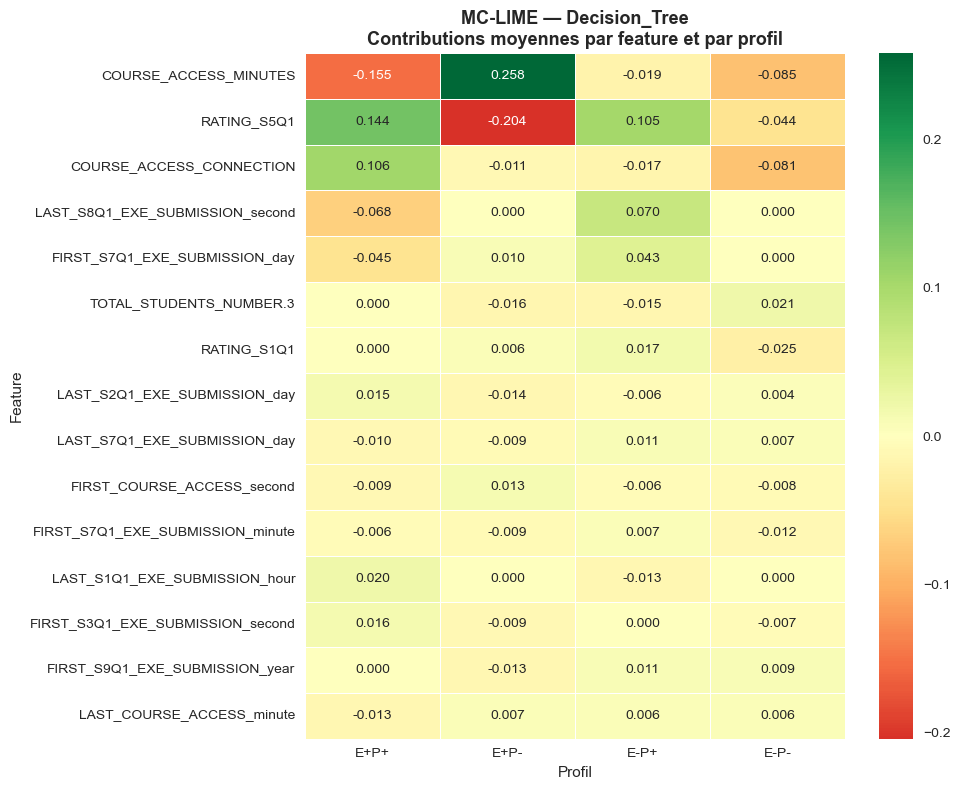

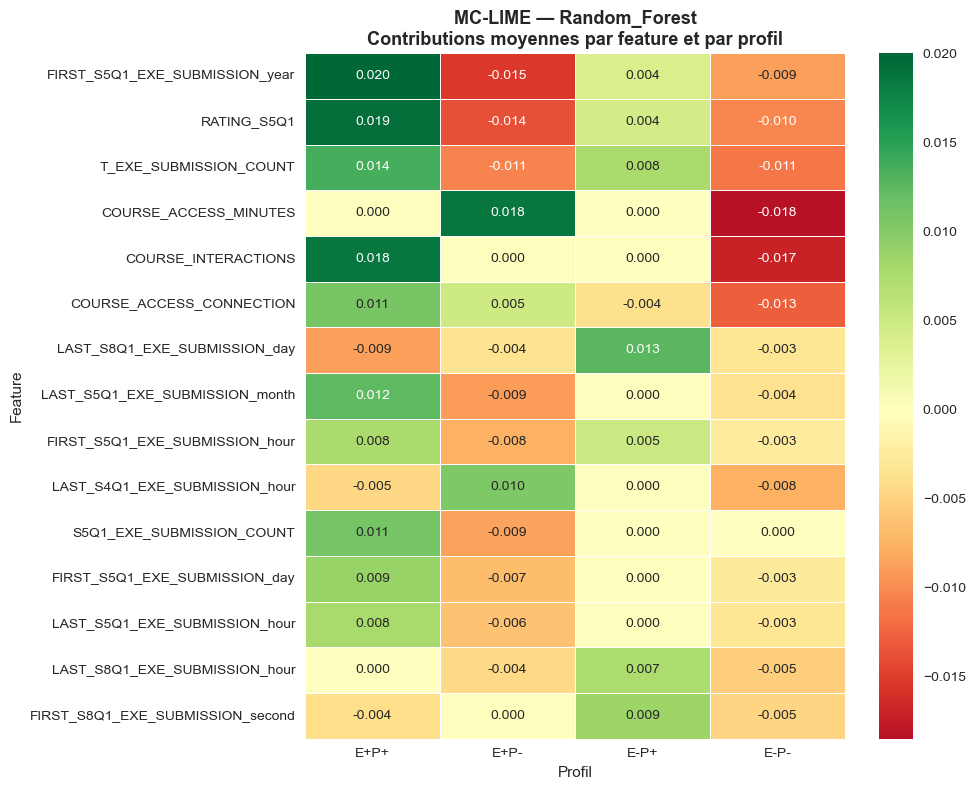

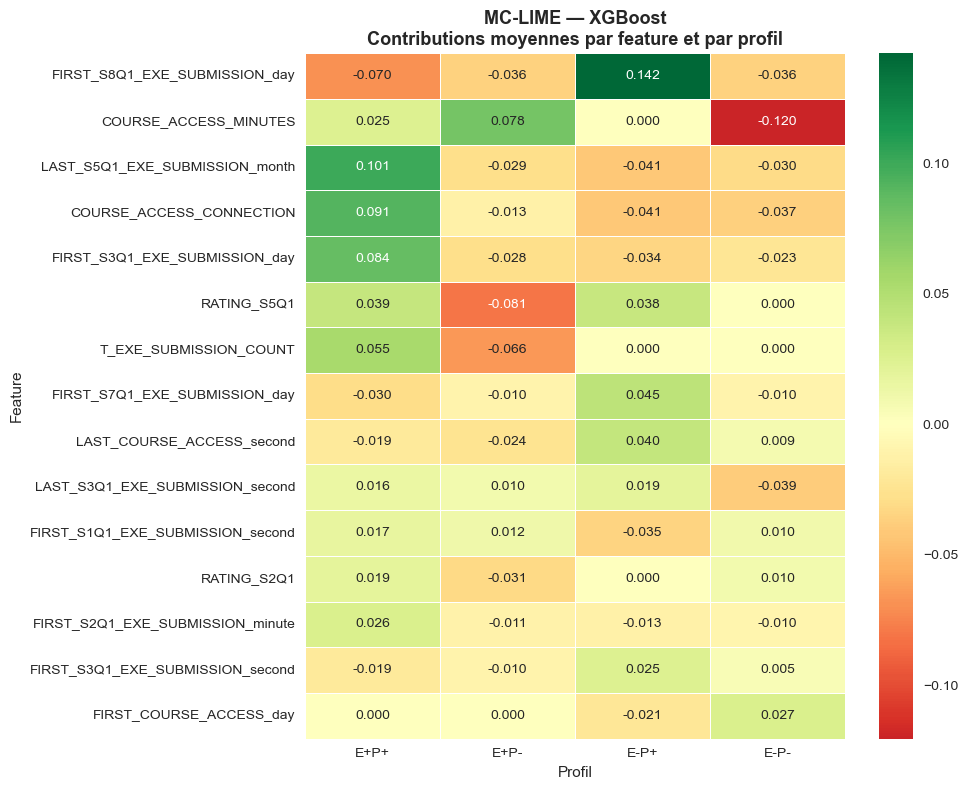

✓ Export : outputs/mclime_explanations.csv
  1480 lignes | 13 instances | 3 modèles

 PIPELINE MC-LIME TERMINÉ !


In [62]:
mc_lime = MCLIMEEvaluator(evaluator)
mc_lime.run()